In [1]:
# =========================================================
# CELL 1: CÀI ĐẶT THƯ VIỆN
# Chỉ cần chạy 1 lần. Sau đó có thể comment dòng này lại.
# =========================================================
!pip install yfinance statsmodels scikit-learn matplotlib pandas numpy seaborn scipy -q

# Kiểm tra version để đảm bảo tương thích
import yfinance; print(f"yfinance: {yfinance.__version__}")
import statsmodels; print(f"statsmodels: {statsmodels.__version__}")
print("✅ Tất cả thư viện đã sẵn sàng!")

yfinance: 1.2.0
statsmodels: 0.14.6
✅ Tất cả thư viện đã sẵn sàng!


In [2]:
# =========================================================
# CELL 2: IMPORT & CẤU HÌNH TOÀN CỤC
# =========================================================
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats

# --- Statsmodels: mô hình chuỗi thời gian ---
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# --- Scikit-learn: tính metrics đánh giá ---
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ===== Cấu hình Matplotlib: clean style, dễ đọc =====
plt.rcParams.update({
    "figure.figsize": (13, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,    # Bỏ đường viền trên
    "axes.spines.right": False,  # Bỏ đường viền phải
    "font.size": 11,
})

# ===== HẰNG SỐ TOÀN CỤC =====
# 📌 Ghim cứng ngày bắt đầu & kết thúc để kết quả reproducible
TICKER     = "VIC.VN"      # Mã cổ phiếu Vingroup trên HOSE
START_DATE = "2024-06-16"  # Bắt đầu lấy data từ đây (~2 năm trước END)
END_DATE   = "2026-06-17"  # Kết thúc: ngày SAU 16/06/2026 (yfinance lấy end-exclusive)
                            # → Dữ liệu thực sự có đến hết ngày 16/06/2026
TEST_SIZE  = 10             # 📌 10 ngày cuối (~ 03-16/06/2026) = bộ test CÓ giá thực
                            # Lý do: có thể so predict vs actual đầy đủ
P_MAX      = 4              # Tìm kiếm p từ 0..4
Q_MAX      = 4              # Tìm kiếm q từ 0..4

# In tóm tắt cấu hình
print("=" * 65)
print(f"  TICKER     : {TICKER}")
print(f"  START_DATE : {START_DATE}")
print(f"  END_DATE   : {END_DATE} (dữ liệu đến hết 16/06/2026)")
print(f"  TEST_SIZE  : {TEST_SIZE} ngày (~ 03–16/06/2026, có giá thực để so)")
print(f"  GRID       : p ∈ [0..{P_MAX}], q ∈ [0..{Q_MAX}]")
print("=" * 65)
print("✅ Sẵn sàng!")

  TICKER     : VIC.VN
  START_DATE : 2024-06-16
  END_DATE   : 2026-06-17 (dữ liệu đến hết 16/06/2026)
  TEST_SIZE  : 10 ngày (~ 03–16/06/2026, có giá thực để so)
  GRID       : p ∈ [0..4], q ∈ [0..4]
✅ Sẵn sàng!


[*********************100%***********************]  1 of 1 completed


📊 Dữ liệu tải được: 522 phiên giao dịch
   Từ: 2024-06-17 → 2026-06-16
   Ngày cuối (TEST cuối): 2026-06-16 ✅
   10 ngày TEST: 2026-06-03 → 2026-06-16
   Giá min :       19,950 VNĐ
   Giá max :      229,800 VNĐ
   Giá TB  :       75,755 VNĐ
   Độ lệch :       64,221 VNĐ


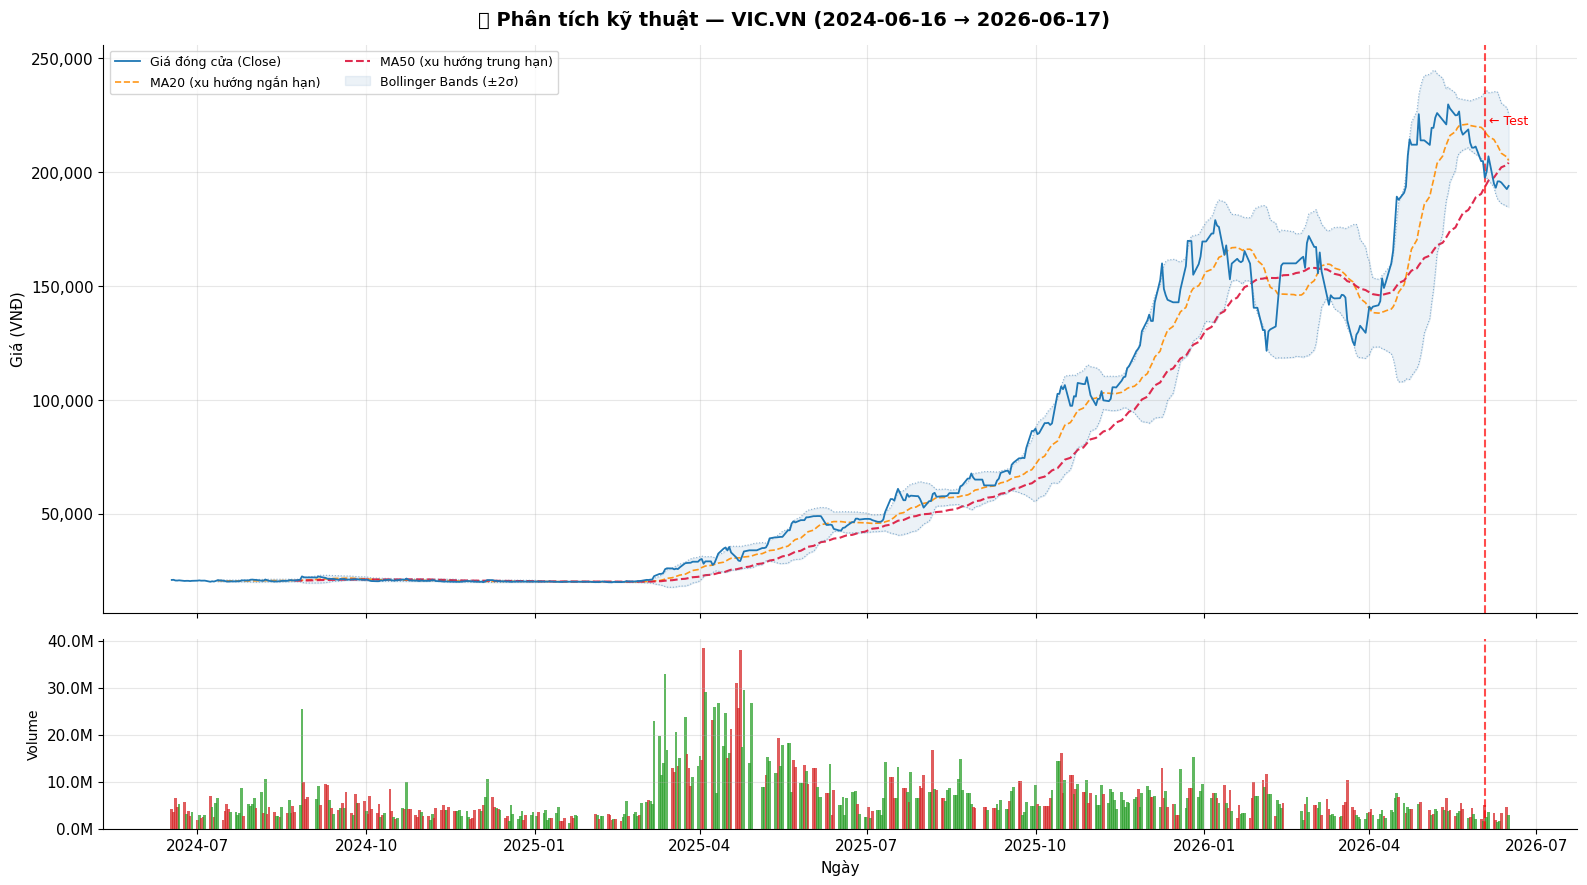

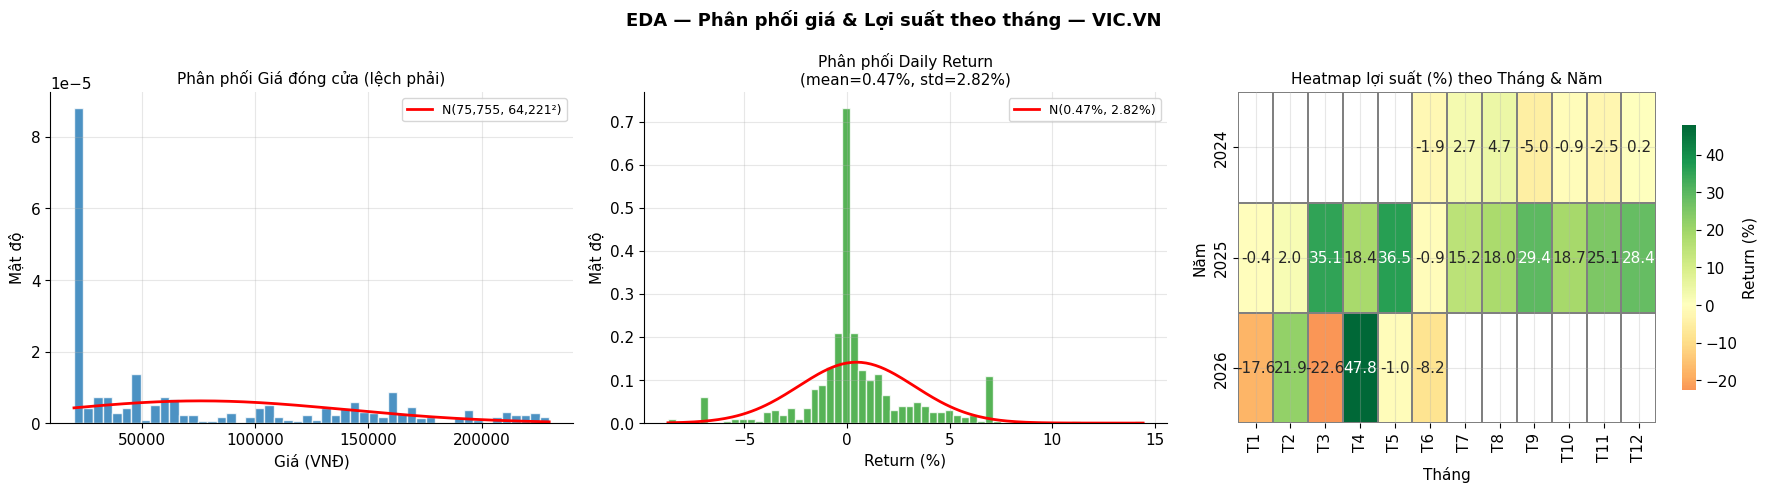


📋 Thống kê mô tả — Giá đóng cửa:
count        522.00
mean      75,755.08
std       64,221.28
min       19,950.00
25%       20,800.00
50%       47,250.00
75%      132,525.00
max      229,800.00
Name: VIC.VN, dtype: object

  Skewness (độ lệch) : 0.8802  (lệch phải)
  Kurtosis (đỉnh nhọn): -0.6091


In [3]:
# =========================================================
# CELL 3: TẢI DỮ LIỆU & EDA TỔNG QUAN
# =========================================================

# ── 1. Tải dữ liệu OHLCV từ Yahoo Finance ─────────────────────
# Dùng start/end thay vì period để ghim cứng ngày → reproducible
# end="2026-06-17" vì yfinance dùng end-exclusive (lấy đến hết 16/06/2026)
raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
raw = raw.dropna()           # Xóa hàng thiếu (ngày nghỉ lễ)
df  = raw["Close"].squeeze() # Lấy cột giá đóng cửa

# Kiểm tra ngày cuối cùng có đúng là 16/06/2026 không
assert str(df.index[-1].date()) <= "2026-06-16", f"Lỗi: ngày cuối {df.index[-1].date()} vượt quá 16/06/2026"

print(f"📊 Dữ liệu tải được: {len(df)} phiên giao dịch")
print(f"   Từ: {df.index[0].date()} → {df.index[-1].date()}")
print(f"   Ngày cuối (TEST cuối): {df.index[-1].date()} ✅")
print(f"   10 ngày TEST: {df.index[-TEST_SIZE].date()} → {df.index[-1].date()}")
print(f"   Giá min : {df.min():>12,.0f} VNĐ")
print(f"   Giá max : {df.max():>12,.0f} VNĐ")
print(f"   Giá TB  : {df.mean():>12,.0f} VNĐ")
print(f"   Độ lệch : {df.std():>12,.0f} VNĐ")

# ── 2. Tính chỉ số kỹ thuật ────────────────────────────────────
ma20  = df.rolling(20).mean()   # MA20: trung bình 20 phiên (ngắn hạn)
ma50  = df.rolling(50).mean()   # MA50: trung bình 50 phiên (trung hạn)
std20 = df.rolling(20).std()    # Độ lệch chuẩn 20 phiên
bb_up = ma20 + 2 * std20        # Bollinger Band trên: vùng quá mua
bb_dn = ma20 - 2 * std20        # Bollinger Band dưới: vùng quá bán

# ── 3. BIỂU ĐỒ 1: Giá + MA + Bollinger Bands + Volume ──────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9),
                                gridspec_kw={"height_ratios": [3, 1]},
                                sharex=True)
fig.suptitle(f"📈 Phân tích kỹ thuật — {TICKER} ({START_DATE} → {END_DATE})",
             fontsize=14, fontweight="bold", y=0.98)
# Panel 1: Đường giá + Chỉ số kỹ thuật
ax1.plot(df.index, df.values, lw=1.3, color="#1f77b4",
         label="Giá đóng cửa (Close)", zorder=3)
ax1.plot(df.index, ma20, lw=1.2, color="#FF8C00", ls="--",
         label="MA20 (xu hướng ngắn hạn)", alpha=0.9)
ax1.plot(df.index, ma50, lw=1.5, color="#DC143C", ls="--",
         label="MA50 (xu hướng trung hạn)", alpha=0.9)
ax1.fill_between(df.index, bb_dn, bb_up,
                 alpha=0.10, color="steelblue", label="Bollinger Bands (±2σ)")
ax1.plot(df.index, bb_up, lw=0.8, color="steelblue", ls=":", alpha=0.6)
ax1.plot(df.index, bb_dn, lw=0.8, color="steelblue", ls=":", alpha=0.6)
ax1.set_ylabel("Giá (VNĐ)", fontsize=11)
ax1.legend(loc="upper left", fontsize=9, ncol=2)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
# Ghi chú vùng train / test
test_start = df.index[-TEST_SIZE]
ax1.axvline(test_start, color="red", ls="--", lw=1.5, alpha=0.7)
ax1.text(test_start, df.max() * 0.98, " ← Test", color="red",
         fontsize=9, va="top")

# Panel 2: Volume (xanh = phiên tăng, đỏ = phiên giảm)
volume  = raw["Volume"].squeeze()
close_s = raw["Close"].squeeze()
open_s  = raw["Open"].squeeze()
colors_vol = ["#d62728" if close_s.iloc[i] < open_s.iloc[i]
              else "#2ca02c" for i in range(len(raw))]
ax2.bar(raw.index, volume, color=colors_vol, alpha=0.75, width=1.5)
ax2.set_ylabel("Volume", fontsize=10)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax2.set_xlabel("Ngày", fontsize=11)
ax2.axvline(test_start, color="red", ls="--", lw=1.5, alpha=0.7)

plt.tight_layout()
plt.show()

# ── 4. BIỂU ĐỒ 2: Phân phối giá & Heatmap lợi suất theo tháng ─
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"EDA — Phân phối giá & Lợi suất theo tháng — {TICKER}",
             fontsize=13, fontweight="bold")

# Subplot 1: Histogram phân phối giá
axes[0].hist(df.values, bins=50, color="#1f77b4",
             edgecolor="white", density=True, alpha=0.8)
mu, sigma = df.mean(), df.std()
xr = np.linspace(df.min(), df.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, mu, sigma),
             "r-", lw=2, label=f"N({mu:,.0f}, {sigma:,.0f}²)")
axes[0].set_title("Phân phối Giá đóng cửa (lệch phải)", fontsize=11)
axes[0].set_xlabel("Giá (VNĐ)")
axes[0].set_ylabel("Mật độ")
axes[0].legend(fontsize=9)

# Subplot 2: Daily Return phân phối
daily_ret = df.pct_change().dropna() * 100  # % thay đổi mỗi ngày
axes[1].hist(daily_ret.values, bins=60, color="#2ca02c",
             edgecolor="white", density=True, alpha=0.8)
mu_r, sig_r = daily_ret.mean(), daily_ret.std()
xr2 = np.linspace(daily_ret.min(), daily_ret.max(), 200)
axes[1].plot(xr2, stats.norm.pdf(xr2, mu_r, sig_r),
             "r-", lw=2, label=f"N({mu_r:.2f}%, {sig_r:.2f}%)")
axes[1].set_title(f"Phân phối Daily Return\n(mean={mu_r:.2f}%, std={sig_r:.2f}%)", fontsize=11)
axes[1].set_xlabel("Return (%)")
axes[1].set_ylabel("Mật độ")
axes[1].legend(fontsize=9)

# Subplot 3: Heatmap lợi suất theo tháng (Month-of-Year)
df_ret = pd.DataFrame({
    "Return": df.pct_change() * 100,
    "Year":   df.index.year,
    "Month":  df.index.month
}).dropna()
monthly = df_ret.groupby(["Year", "Month"])["Return"].sum().unstack()
months = ["T1","T2","T3","T4","T5","T6","T7","T8","T9","T10","T11","T12"]
monthly.columns = [months[m-1] for m in monthly.columns]
sns.heatmap(monthly, ax=axes[2], annot=True, fmt=".1f",
            cmap="RdYlGn", center=0,
            linewidths=0.3, linecolor="gray",
            cbar_kws={"label": "Return (%)", "shrink": 0.8})
axes[2].set_title("Heatmap lợi suất (%) theo Tháng & Năm", fontsize=11)
axes[2].set_xlabel("Tháng")
axes[2].set_ylabel("Năm")

plt.tight_layout()
plt.show()

# ── 5. Thống kê mô tả đầy đủ ───────────────────────────────────
print("\n📋 Thống kê mô tả — Giá đóng cửa:")
print(df.describe().apply(lambda x: f"{x:,.2f}"))
print(f"\n  Skewness (độ lệch) : {df.skew():.4f}  "
      f"({'lệch phải' if df.skew() > 0 else 'lệch trái'})")
print(f"  Kurtosis (đỉnh nhọn): {df.kurtosis():.4f}")

## 2. Kiểm định tính dừng (ADF Test) — Xác định tham số d

  BƯỚC 1: Kiểm định chuỗi GIÁ GỐC
[ADF — Giá đóng cửa gốc]
  Test Statistic  : 0.2823
  p-value         : 0.976517  →  KHÔNG DỪNG ❌
  Số lags dùng    : 18
  Giá trị tới hạn : 1%=-3.443 | 5%=-2.867 | 10%=-2.570
  Ngưỡng quyết định: α = 0.05

  BƯỚC 2: Kiểm định SAI PHÂN BẬC 1
[ADF — Sai phân bậc 1 (d=1)]
  Test Statistic  : -5.5349
  p-value         : 0.000002  →  DỪNG ✅
  Số lags dùng    : 17
  Giá trị tới hạn : 1%=-3.443 | 5%=-2.867 | 10%=-2.570
  Ngưỡng quyết định: α = 0.05

→ Kết luận: Cần sai phân 1 lần → d = 1
  (Phổ biến nhất với chuỗi giá cổ phiếu)


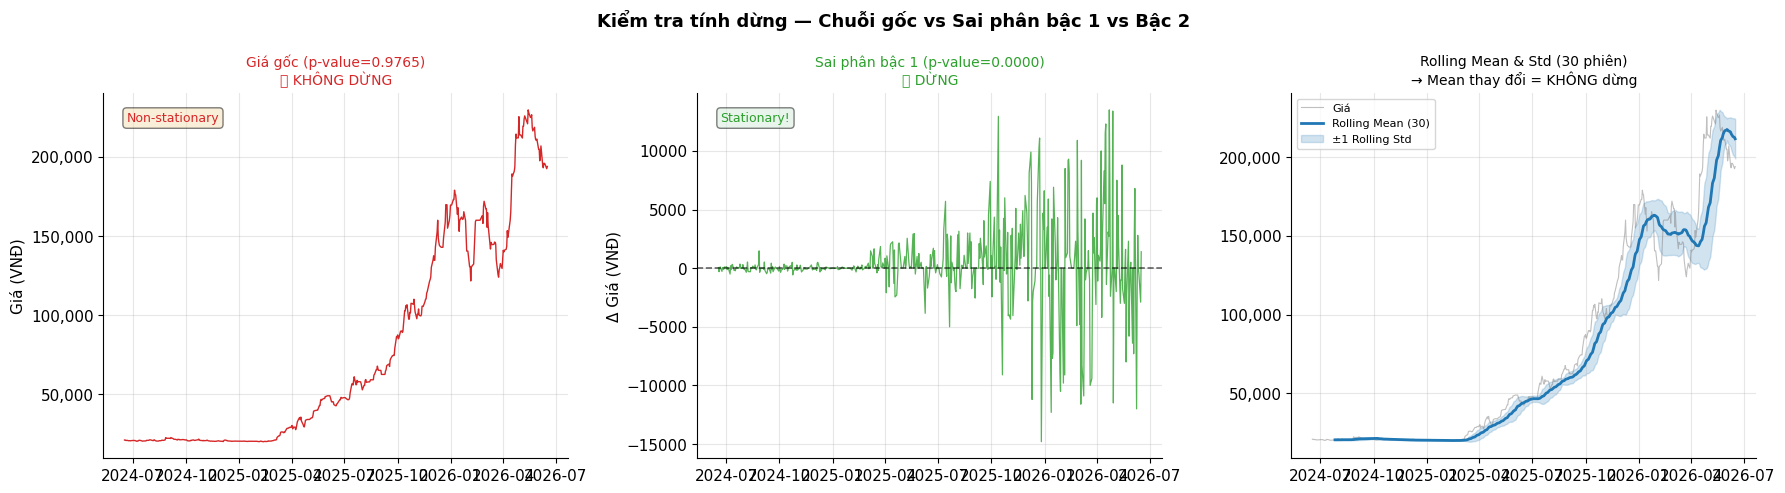


✅ Tham số d = 1 đã được xác định!
   Dùng giá trị này cho bước Grid Search ở Cell tiếp theo.


In [4]:
# =========================================================
# CELL 4: KIỂM ĐỊNH TÍNH DỪNG (ADF TEST) — TÌM THAM SỐ d
# =========================================================
# 📌 KIẾN THỨC NỀN:
#   Chuỗi DỪNG (stationary) = mean, variance, autocovariance không đổi theo t
#   Giá cổ phiếu thường KHÔNG dừng vì có xu hướng dài hạn
#   Sai phân bậc 1: Δy_t = y_t - y_{t-1} (chênh lệch giá mỗi ngày)
#   ARIMA(p,d,q): tham số d = số lần sai phân cần thiết để chuỗi dừng
# =========================================================

def adf_report(series, label=""):
    """
    Chạy kiểm định ADF (Augmented Dickey-Fuller) và in kết quả.
    H0: Chuỗi có unit root → KHÔNG dừng
    H1: Chuỗi không có unit root → DỪNG
    Bác bỏ H0 khi p-value < 0.05 → chuỗi DỪNG
    """
    result  = adfuller(series, autolag="AIC")  # autolag: tự chọn số lag tối ưu
    stat    = result[0]   # Test statistic (càng âm → càng dừng)
    p_val   = result[1]   # p-value (< 0.05 → bác bỏ H0 → DỪNG)
    n_lags  = result[2]   # Số lags được sử dụng
    crit    = result[4]   # Giá trị tới hạn tại 1%, 5%, 10%
    status  = "DỪNG ✅" if p_val < 0.05 else "KHÔNG DỪNG ❌"

    print(f"[ADF — {label}]")
    print(f"  Test Statistic  : {stat:.4f}")
    print(f"  p-value         : {p_val:.6f}  →  {status}")
    print(f"  Số lags dùng    : {n_lags}")
    print(f"  Giá trị tới hạn : 1%={crit['1%']:.3f} | 5%={crit['5%']:.3f} | 10%={crit['10%']:.3f}")
    print(f"  Ngưỡng quyết định: α = 0.05\n")
    return p_val

# ── Chạy ADF trên chuỗi giá gốc ────────────────────────────────
print("=" * 60)
print("  BƯỚC 1: Kiểm định chuỗi GIÁ GỐC")
print("=" * 60)
p_orig = adf_report(df, "Giá đóng cửa gốc")

# ── Sai phân bậc 1 và kiểm định lại ───────────────────────────
df_d1 = df.diff().dropna()   # Δy_t = y_t - y_{t-1}
print("=" * 60)
print("  BƯỚC 2: Kiểm định SAI PHÂN BẬC 1")
print("=" * 60)
p_d1 = adf_report(df_d1, "Sai phân bậc 1 (d=1)")

# ── Kết luận tham số d ─────────────────────────────────────────
print("=" * 60)
if p_orig < 0.05:
    d_opt = 0
    print("→ Kết luận: Chuỗi gốc đã dừng → d = 0")
elif p_d1 < 0.05:
    d_opt = 1
    print("→ Kết luận: Cần sai phân 1 lần → d = 1")
    print("  (Phổ biến nhất với chuỗi giá cổ phiếu)")
else:
    d_opt = 2
    print("→ Kết luận: Cần sai phân 2 lần → d = 2 (hiếm gặp)")
print("=" * 60)

# ── BIỂU ĐỒ: So sánh trực quan 3 chuỗi ────────────────────────
df_d2 = df_d1.diff().dropna()   # Sai phân bậc 2 (để tham khảo)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Kiểm tra tính dừng — Chuỗi gốc vs Sai phân bậc 1 vs Bậc 2",
             fontsize=13, fontweight="bold")

# Panel 1: Giá gốc
axes[0].plot(df.index, df.values, lw=1, color="#d62728")
axes[0].set_title(f"Giá gốc (p-value={p_orig:.4f})\n❌ KHÔNG DỪNG",
                  fontsize=10, color="#d62728")
axes[0].set_ylabel("Giá (VNĐ)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].text(0.05, 0.95, "Non-stationary", transform=axes[0].transAxes,
             fontsize=9, color="#d62728", va="top",
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

# Panel 2: Sai phân bậc 1
axes[1].plot(df_d1.index, df_d1.values, lw=0.9, color="#2ca02c", alpha=0.8)
axes[1].axhline(0, color="black", lw=1.2, ls="--", alpha=0.6)
axes[1].set_title(f"Sai phân bậc 1 (p-value={p_d1:.4f})\n✅ DỪNG",
                  fontsize=10, color="#2ca02c")
axes[1].set_ylabel("Δ Giá (VNĐ)")
axes[1].text(0.05, 0.95, "Stationary!", transform=axes[1].transAxes,
             fontsize=9, color="#2ca02c", va="top",
             bbox=dict(boxstyle="round", facecolor="#d4edda", alpha=0.5))

# Panel 3: Rolling Mean & Std để minh họa tính dừng
roll_mean = df.rolling(30).mean()
roll_std  = df.rolling(30).std()
axes[2].plot(df.index, df.values, lw=0.8, color="gray", alpha=0.5, label="Giá")
axes[2].plot(df.index, roll_mean, lw=2, color="#1f77b4", label="Rolling Mean (30)")
axes[2].fill_between(df.index,
                      roll_mean - roll_std,
                      roll_mean + roll_std,
                      alpha=0.2, color="#1f77b4", label="±1 Rolling Std")
axes[2].set_title("Rolling Mean & Std (30 phiên)\n→ Mean thay đổi = KHÔNG dừng",
                  fontsize=10)
axes[2].legend(fontsize=8)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

print(f"\n✅ Tham số d = {d_opt} đã được xác định!")
print("   Dùng giá trị này cho bước Grid Search ở Cell tiếp theo.")

## 3. ACF & PACF → gợi ý p, q

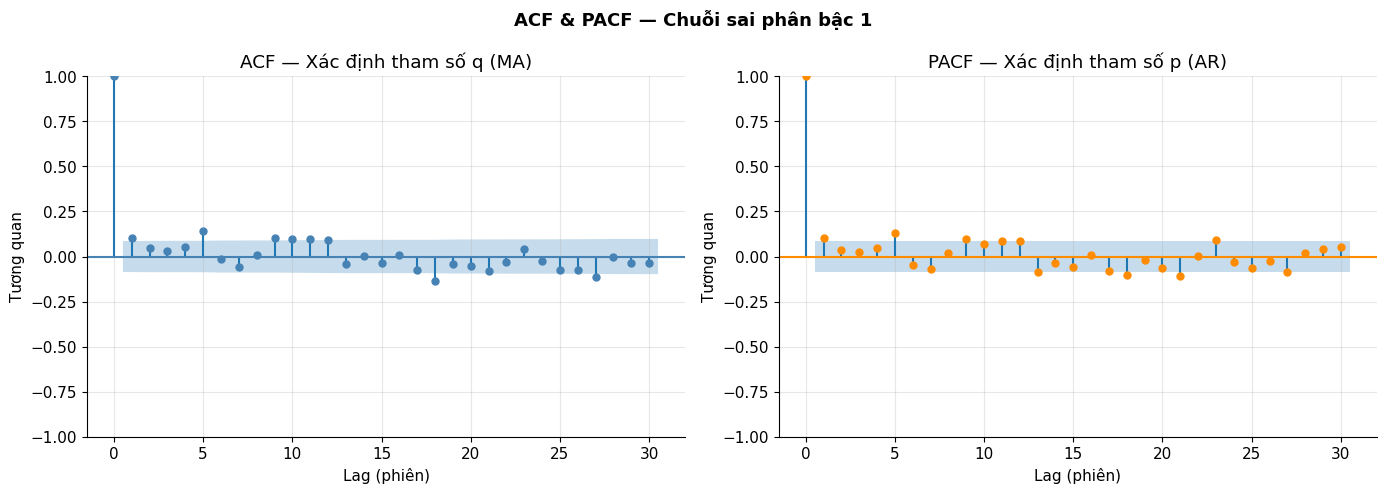


📖 Cách đọc đồ thị:
─────────────────────────────────────────────────
▸ ACF  (AutoCorrelation Function):
  → Nếu cắt về 0 tại lag k  →  MA(k), tức q = k
  → Nếu giảm dần từ từ       →  có thành phần AR

▸ PACF (Partial AutoCorrelation Function):
  → Nếu cắt về 0 tại lag k  →  AR(k), tức p = k
  → Nếu giảm dần từ từ       →  có thành phần MA

▸ Vùng xanh nhạt = khoảng tin cậy 95%.
  Các thanh vượt ra ngoài vùng này là có ý nghĩa thống kê.
─────────────────────────────────────────────────



In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ACF & PACF — Chuỗi sai phân bậc 1", fontsize=13, fontweight="bold")

plot_acf(df_d1,  lags=30, ax=axes[0], title="ACF — Xác định tham số q (MA)",  color="steelblue")
plot_pacf(df_d1, lags=30, ax=axes[1], title="PACF — Xác định tham số p (AR)", color="darkorange")

for ax in axes:
    ax.set_xlabel("Lag (phiên)")
    ax.set_ylabel("Tương quan")

plt.tight_layout()
plt.show()

print("""
📖 Cách đọc đồ thị:
─────────────────────────────────────────────────
▸ ACF  (AutoCorrelation Function):
  → Nếu cắt về 0 tại lag k  →  MA(k), tức q = k
  → Nếu giảm dần từ từ       →  có thành phần AR

▸ PACF (Partial AutoCorrelation Function):
  → Nếu cắt về 0 tại lag k  →  AR(k), tức p = k
  → Nếu giảm dần từ từ       →  có thành phần MA

▸ Vùng xanh nhạt = khoảng tin cậy 95%.
  Các thanh vượt ra ngoài vùng này là có ý nghĩa thống kê.
─────────────────────────────────────────────────
""")

## 4. Grid-search AIC/BIC → ARIMA tốt nhất

📐 Tập Train: 512 phiên (2024-06-17 → 2026-06-02)
   Tập Test : 10 phiên (2026-06-03 → 2026-06-16) ← có giá thực
🔍 Đang Grid Search (p,q) ∈ [0..4]×[0..4] với d=1 ...


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\


📊 Bảng kết quả Grid Search (sắp xếp theo AIC tăng dần):
 p  d  q         AIC         BIC
 2  1  4 9698.171376 9727.825963
 4  1  2 9698.655434 9728.310021
 3  1  3 9699.192047 9728.846635
 4  1  3 9703.505638 9737.396595
 3  1  4 9703.744158 9737.635115
 1  1  1 9705.370005 9718.079114
 4  1  4 9705.692679 9743.820006
 2  1  1 9706.612281 9723.557759
 1  1  0 9707.815030 9716.287769
 2  1  0 9708.197604 9720.906712

🏆 Tốt nhất: ARIMA(2,1,4)  AIC=9698.17  BIC=9727.83


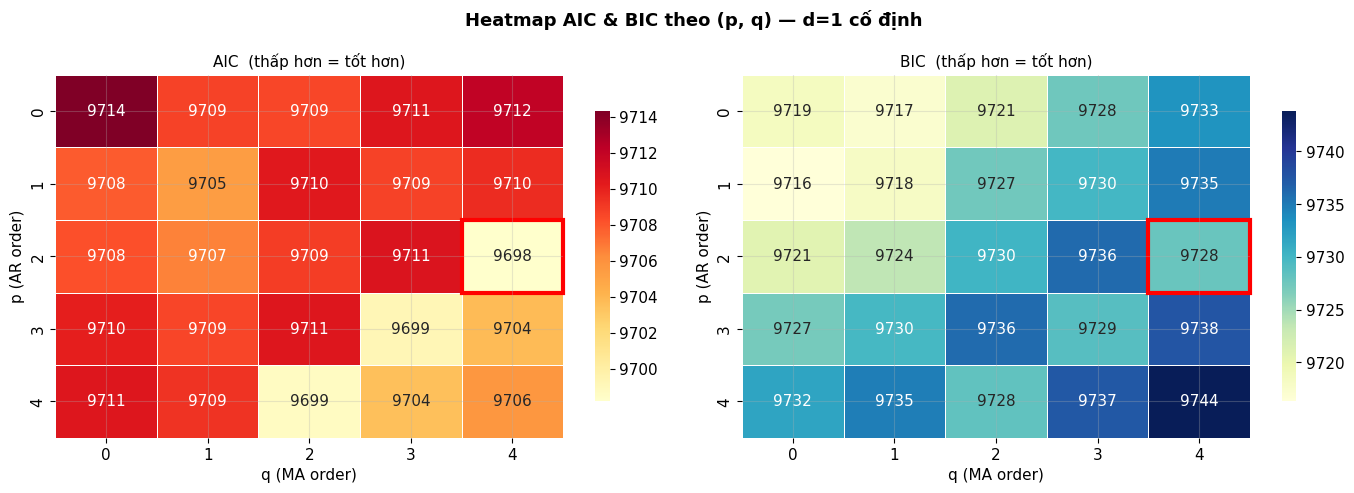

In [6]:
train = df.iloc[:-TEST_SIZE]  # Train = tất cả trừ 10 ngày test cuối
test  = df.iloc[-TEST_SIZE:]  # Test  = 10 ngày (~ 03–16/06/2026, CÓ giá thực)
print(f"📐 Tập Train: {len(train)} phiên ({train.index[0].date()} → {train.index[-1].date()})")
print(f"   Tập Test : {TEST_SIZE} phiên ({test.index[0].date()} → {test.index[-1].date()}) ← có giá thực")
print(f"🔍 Đang Grid Search (p,q) ∈ [0..{P_MAX}]×[0..{Q_MAX}] với d=1 ...")

results = []
for p in range(P_MAX + 1):
    for q in range(Q_MAX + 1):
        try:
            m = ARIMA(train, order=(p, 1, q)).fit()
            results.append({"p": p, "d": 1, "q": q, "AIC": m.aic, "BIC": m.bic})
        except:
            pass

res_df = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
print("\n📊 Bảng kết quả Grid Search (sắp xếp theo AIC tăng dần):")
print(res_df.head(10).to_string(index=False))

best    = res_df.iloc[0]
p_opt   = int(best.p)
d_opt   = int(best.d)
q_opt   = int(best.q)
print(f"\n🏆 Tốt nhất: ARIMA({p_opt},{d_opt},{q_opt})  AIC={best.AIC:.2f}  BIC={best.BIC:.2f}")

# ── Heatmap AIC & BIC ──────────────────────────────────────────
aic_matrix = res_df.pivot_table(index="p", columns="q", values="AIC")
bic_matrix = res_df.pivot_table(index="p", columns="q", values="BIC")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Heatmap AIC & BIC theo (p, q) — d=1 cố định", fontsize=13, fontweight="bold")

for ax, matrix, title, cmap in zip(
    axes,
    [aic_matrix, bic_matrix],
    ["AIC  (thấp hơn = tốt hơn)", "BIC  (thấp hơn = tốt hơn)"],
    ["YlOrRd", "YlGnBu"]
):
    sns.heatmap(matrix, ax=ax, annot=True, fmt=".0f", cmap=cmap,
                linewidths=0.5, linecolor="white", cbar_kws={"shrink": 0.8})
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("q (MA order)")
    ax.set_ylabel("p (AR order)")
    ax.add_patch(plt.Rectangle((q_opt, p_opt), 1, 1, fill=False,
                                edgecolor="red", lw=3, clip_on=False))

plt.tight_layout()
plt.show()

## 5. Mô hình AR và MA (dùng ARIMA với q=0 và p=0)

In [7]:
# ── Huấn luyện 3 mô hình (theo VIC_ARIMA_analysis.md) ────────
# AR(p)        = ARIMA(p_opt, 1, 0)         : Tự hồi quy thuần túy
# MA(q)        = ARIMA(0,    1, q_opt)      : Trung bình trượt thuần túy
# ARIMA(p,d,q) = ARIMA(p_opt, d_opt, q_opt) : Mô hình kết hợp (tốt nhất theo AIC)
ar_model    = ARIMA(train, order=(p_opt, 1, 0)).fit()
ma_model    = ARIMA(train, order=(0, 1, q_opt)).fit()
arima_model = ARIMA(train, order=(p_opt, d_opt, q_opt)).fit()

models_fitted = {"AR": ar_model, "MA": ma_model, "ARIMA": arima_model}
orders        = {
    "AR":    (p_opt, 1, 0),
    "MA":    (0, 1, q_opt),
    "ARIMA": (p_opt, d_opt, q_opt),
}

# ── Bảng so sánh AIC/BIC/Log-Likelihood ──────────────────────
print(f"{'Mô hình':<10} {'Order':<15} {'AIC':>10} {'BIC':>10} {'Log-Lik':>12}")
print("─" * 62)
for name, m in models_fitted.items():
    o = orders[name]
    print(f"{name:<10} ARIMA{str(o):<11} {m.aic:>10.2f} {m.bic:>10.2f} {m.llf:>12.2f}")

# ── In summary mô hình ARIMA tốt nhất ────────────────────────
print(f"\n{'='*60}")
print(f"📋 Model Summary — ARIMA({p_opt},{d_opt},{q_opt}) [Tốt nhất theo AIC]")
print(f"{'='*60}")
print(arima_model.summary())

d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

Mô hình    Order                  AIC        BIC      Log-Lik
──────────────────────────────────────────────────────────────
AR         ARIMA(2, 1, 0)      9708.20    9720.91     -4851.10
MA         ARIMA(0, 1, 4)      9712.07    9733.25     -4851.03
ARIMA      ARIMA(2, 1, 4)      9698.17    9727.83     -4842.09

📋 Model Summary — ARIMA(2,1,4) [Tốt nhất theo AIC]
                               SARIMAX Results                                
Dep. Variable:                 VIC.VN   No. Observations:                  512
Model:                 ARIMA(2, 1, 4)   Log Likelihood               -4842.086
Date:                Wed, 24 Jun 2026   AIC                           9698.171
Time:                        13:03:13   BIC                           9727.826
Sample:                    06-17-2024   HQIC                          9709.797
                         - 06-02-2026                                         
Covariance Type:                  opg                                         
  

## 6. Đánh giá 10 ngày có giá thực tế (03–16/06/2026)

> **Lý do chọn 10 ngày này:** Đây là 10 ngày giao dịch cuối cùng trong dữ liệu,
> kết thúc ngày 16/06/2026. Vì đã có **giá đóng cửa thực tế** của những ngày này,
> chúng ta có thể đánh giá chính xác hiệu suất của mô hình.
> → Đây mới là đánh giá **có ý nghĩa thực sự**, không phải "dự báo mù".

In [8]:
# =========================================================
# CELL 13: WALK-FORWARD BACKTEST — 10 NGÀY (03–16/06/2026)
# =========================================================
# 📌 CHIẾN LƯỢC WALK-FORWARD:
#   - test = 10 ngày cuối, TẤT CẢ đều có giá đóng cửa thực tế
#   - Mỗi bước t: fit(data[0..N-10+t]) → predict(N-10+t+1)
#   - Không "nhìn trước" dữ liệu tương lai → không Data Leakage
#   - So sánh predict vs actual → tính MAE, RMSE, MAPE
# =========================================================

# test đã được khai báo ở Cell 9 (10 ngày cuối)
preds = {}

print("⏳ Walk-Forward Rolling Forecast — 10 ngày (03–16/06/2026)...")
print(f"   Train kết thúc: {train.index[-1].date()}")
print(f"   Test : {test.index[0].date()} → {test.index[-1].date()} ({TEST_SIZE} phiên)\n")

for name, order in orders.items():
    fc = []
    for i in range(TEST_SIZE):
        # Chỉ dùng dữ liệu từ đầu đến phiên thứ (N-10+i)
        window_data = df.iloc[:len(train) + i]  # Không nhìn trước
        m = ARIMA(window_data, order=order).fit()
        fc.append(m.forecast(1).iloc[0])
    preds[name] = pd.Series(fc, index=test.index)
    print(f"  ✅ {name} ARIMA{order} xong")

# ── Tính metrics đánh giá ─────────────────────────────────────
metrics = {}
print(f"\n{'─'*58}")
print(f"{'Mô hình':<10} {'MAE (VNĐ)':>12} {'RMSE (VNĐ)':>13} {'MAPE (%)':>10}")
print(f"{'─'*58}")
for name, pred in preds.items():
    mae  = mean_absolute_error(test, pred)
    rmse = np.sqrt(mean_squared_error(test, pred))
    mape = np.mean(np.abs((test.values - pred.values) / test.values)) * 100
    metrics[name] = {"MAE": mae, "RMSE": rmse, "MAPE": mape}
    verdict = "✅" if mape < 5 else "⚠️"
    print(f"{name:<10} {mae:>12,.1f} {rmse:>13,.1f} {mape:>10.2f}% {verdict}")

print(f"{'─'*58}")
best_model = min(metrics, key=lambda k: metrics[k]["MAPE"])
print(f"🏆 Mô hình tốt nhất: {best_model}  (MAPE={metrics[best_model]['MAPE']:.2f}%)")
mape_best = metrics[best_model]['MAPE']
print(f"{'✅ ĐẠT mục tiêu MAPE < 5%' if mape_best < 5 else '⚠️ CHƯA đạt mục tiêu MAPE < 5%'}")

⏳ Walk-Forward Rolling Forecast — 10 ngày (03–16/06/2026)...
   Train kết thúc: 2026-06-02
   Test : 2026-06-03 → 2026-06-16 (10 phiên)



d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

  ✅ AR ARIMA(2, 1, 0) xong


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

  ✅ MA ARIMA(0, 1, 4) xong


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

  ✅ ARIMA ARIMA(2, 1, 4) xong

──────────────────────────────────────────────────────────
Mô hình       MAE (VNĐ)    RMSE (VNĐ)   MAPE (%)
──────────────────────────────────────────────────────────
AR              4,018.3       5,485.4       2.03% ✅
MA              3,936.1       5,500.2       1.99% ✅
ARIMA           3,871.3       5,356.2       1.96% ✅
──────────────────────────────────────────────────────────
🏆 Mô hình tốt nhất: ARIMA  (MAPE=1.96%)
✅ ĐẠT mục tiêu MAPE < 5%


## 7. Biểu đồ backtest

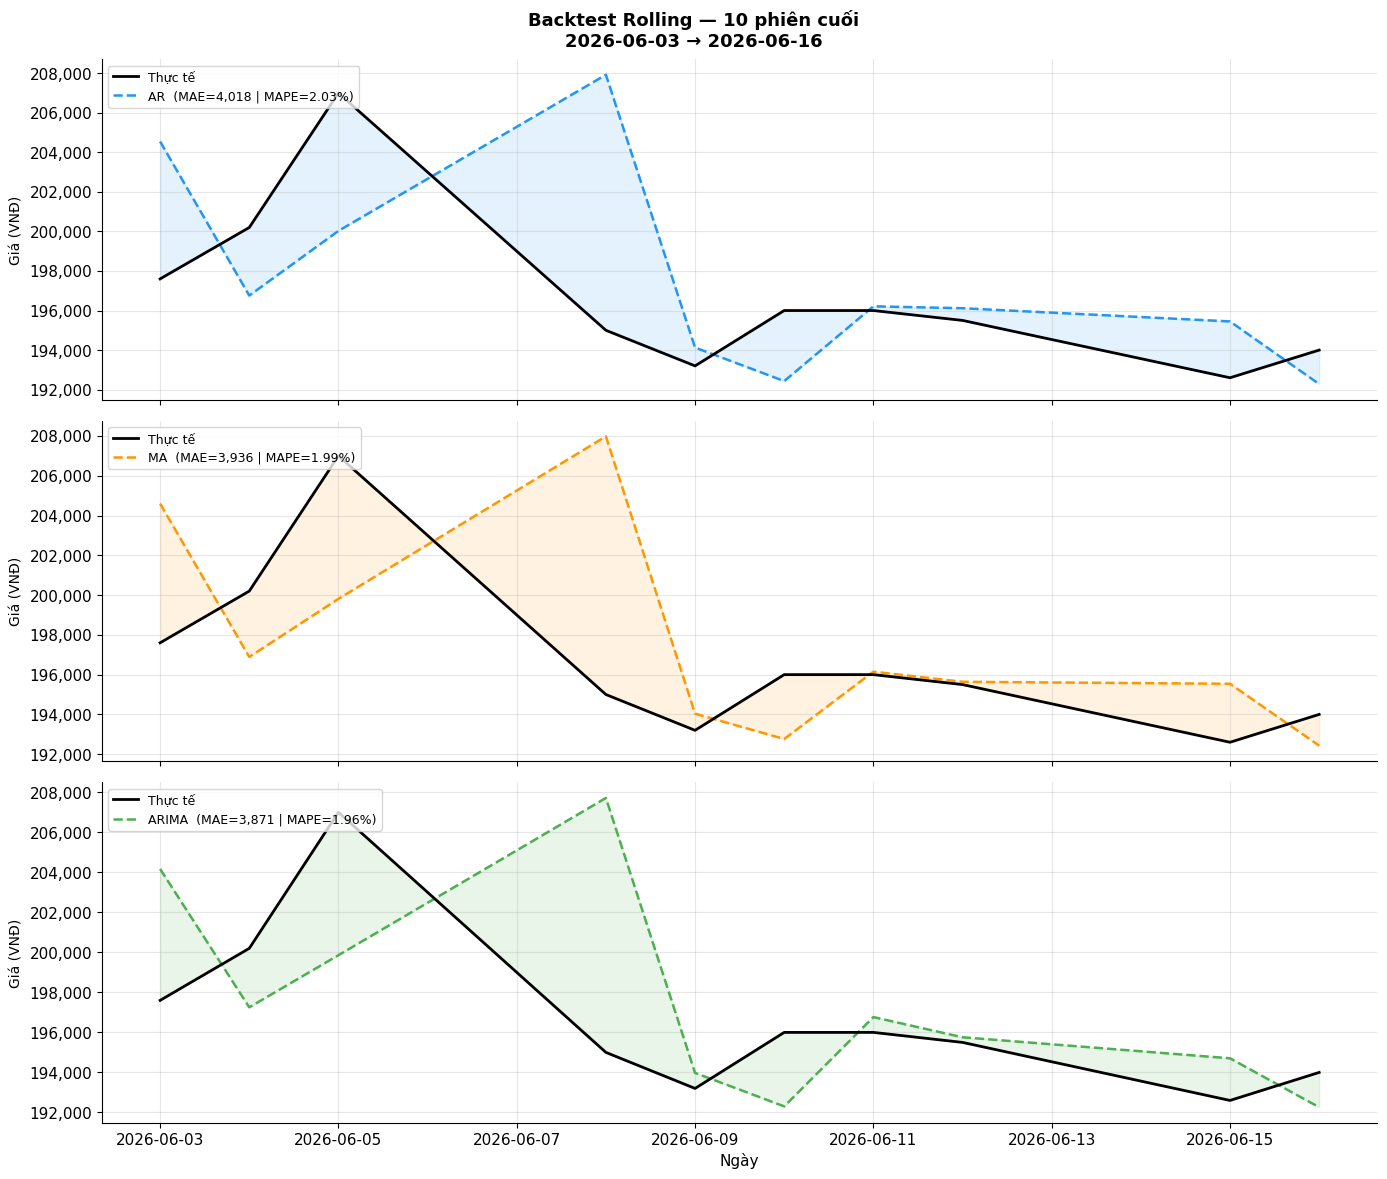

In [9]:
colors = {"AR": "#2196F3", "MA": "#FF9800", "ARIMA": "#4CAF50"}

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f"Backtest Rolling — {TEST_SIZE} phiên cuối\n"
             f"{test.index[0].date()} → {test.index[-1].date()}",
             fontsize=13, fontweight="bold")

for ax, (name, pred) in zip(axes, preds.items()):
    m = metrics[name]
    ax.plot(test.index, test.values, "k-", lw=2.0, label="Thực tế", zorder=3)
    ax.plot(pred.index, pred.values, "--", lw=1.8, color=colors[name],
            label=f"{name}  (MAE={m['MAE']:,.0f} | MAPE={m['MAPE']:.2f}%)")
    ax.fill_between(test.index, test.values, pred.values,
                    alpha=0.12, color=colors[name])
    ax.set_ylabel("Giá (VNĐ)", fontsize=10)
    ax.legend(loc="upper left", fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[-1].set_xlabel("Ngày")
plt.tight_layout()
plt.show()

## 8. So sánh hiệu suất 3 mô hình

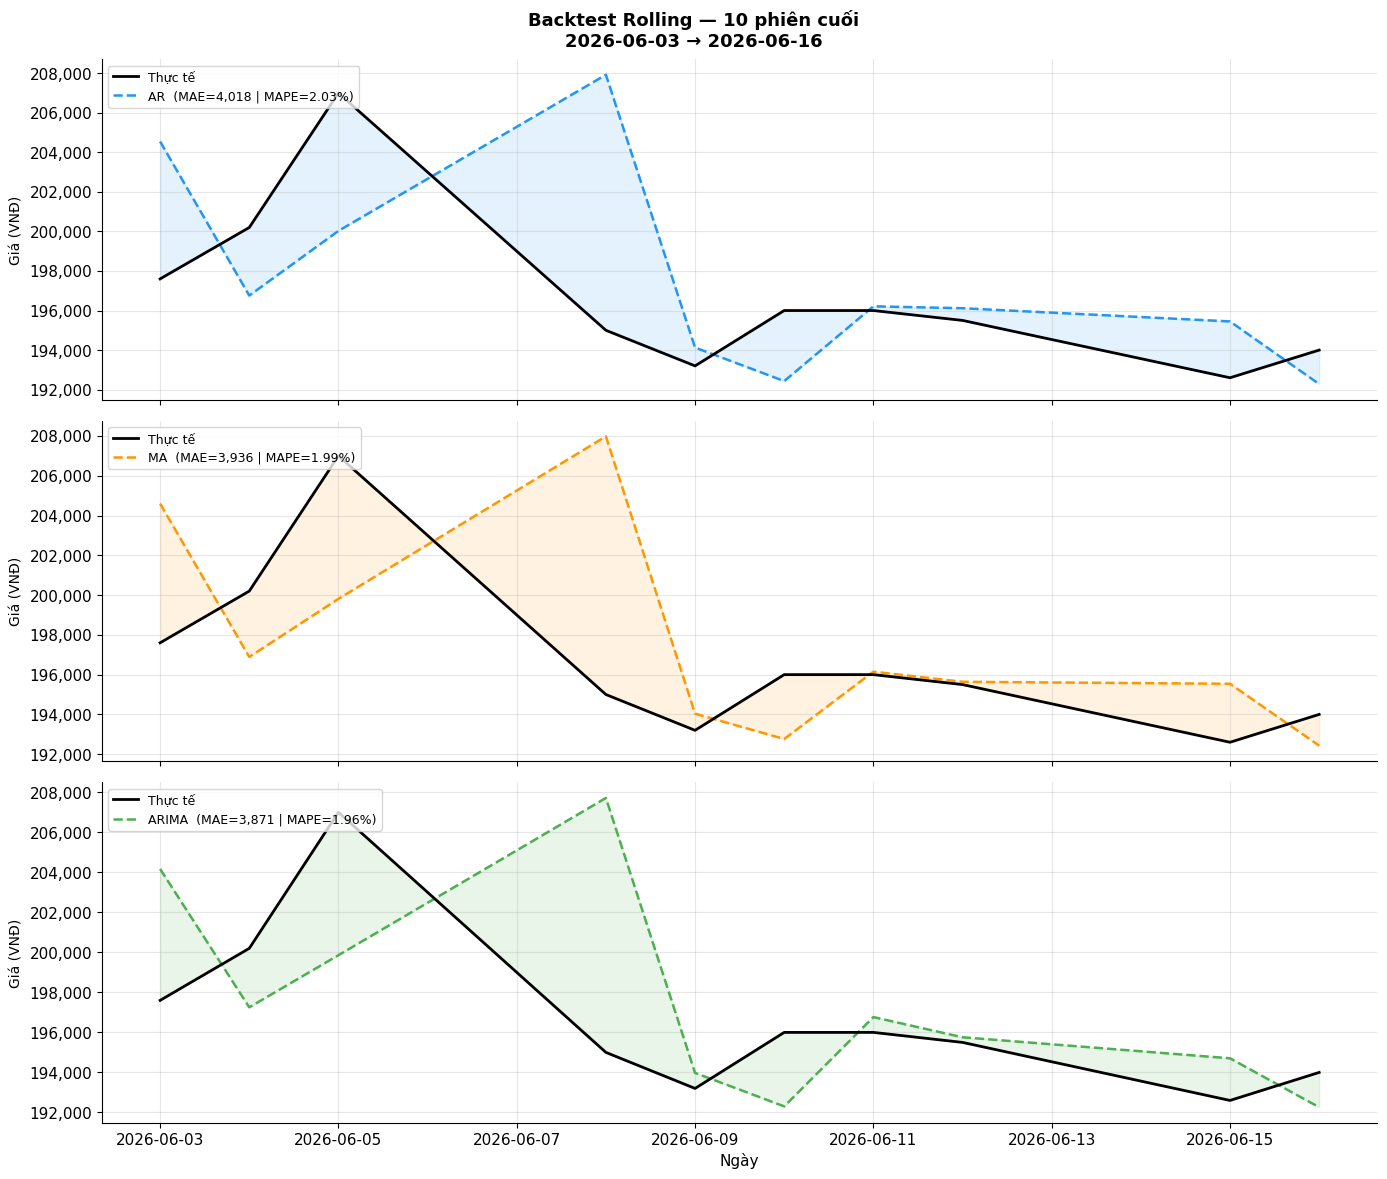


  BẢNG SO SÁNH — Giá Thực Tế vs Dự Báo  (10 ngày test)
Ngày           Thực Tế (VNĐ) │     AR Dự báo  Lệch % │     MA Dự báo  Lệch % │  ARIMA Dự báo  Lệch %
───────────────────────────────────────────────────────────────────────────
2026-06-03           197,600 │       204,551  +3.52% │       204,601  +3.54% │       204,166  +3.32%
2026-06-04           200,200 │       196,757  -1.72% │       196,889  -1.65% │       197,253  -1.47%
2026-06-05           207,000 │       200,028  -3.37% │       199,810  -3.47% │       199,858  -3.45%
2026-06-08           195,000 │       207,924  +6.63% │       207,981  +6.66% │       207,716  +6.52%
2026-06-09           193,200 │       194,128  +0.48% │       194,038  +0.43% │       193,977  +0.40%
2026-06-10           196,000 │       192,432  -1.82% │       192,763  -1.65% │       192,303  -1.89%
2026-06-11           196,000 │       196,213  +0.11% │       196,149  +0.08% │       196,766  +0.39%
2026-06-12           195,500 │       196,116  +0.32% │      

In [31]:
colors = {"AR": "#2196F3", "MA": "#FF9800", "ARIMA": "#4CAF50"}

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f"Backtest Rolling — {TEST_SIZE} phiên cuối\n"
             f"{test.index[0].date()} → {test.index[-1].date()}",
             fontsize=13, fontweight="bold")

for ax, (name, pred) in zip(axes, preds.items()):
    m = metrics[name]
    ax.plot(test.index, test.values, "k-", lw=2.0, label="Thực tế", zorder=3)
    ax.plot(pred.index, pred.values, "--", lw=1.8, color=colors[name],
            label=f"{name}  (MAE={m['MAE']:,.0f} | MAPE={m['MAPE']:.2f}%)")
    ax.fill_between(test.index, test.values, pred.values,
                    alpha=0.12, color=colors[name])
    ax.set_ylabel("Giá (VNĐ)", fontsize=10)
    ax.legend(loc="upper left", fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[-1].set_xlabel("Ngày")
plt.tight_layout()
plt.show()

# ── BẢNG CHI TIẾT: Giá thực vs Giá dự báo từng ngày ─────────────
print("\n" + "=" * 75)
print(f"  BẢNG SO SÁNH — Giá Thực Tế vs Dự Báo  ({TEST_SIZE} ngày test)")
print("=" * 75)

# Header
header = f"{'Ngày':<13} {'Thực Tế (VNĐ)':>14}"
for name in preds:
    header += f" │ {name+' Dự báo':>13} {'Lệch %':>7}"
print(header)
print("─" * 75)

# Từng ngày
for i, date in enumerate(test.index):
    actual = test.iloc[i]
    row = f"{str(date.date()):<13} {actual:>14,.0f}"
    for name, pred in preds.items():
        p   = pred.iloc[i]
        err = (p - actual) / actual * 100
        sign = "+" if err >= 0 else ""
        row += f" │ {p:>13,.0f} {sign+f'{err:.2f}%':>7}"
    print(row)

print("─" * 75)

# Dòng MAPE tổng kết
footer = f"{'MAPE':.<13} {'':>14}"
for name in preds:
    footer += f" │ {'':>13} {metrics[name]['MAPE']:.2f}%  "
print(footer)
print("=" * 75)

# Tóm tắt nhanh
print(f"\n📌 Tóm tắt ({test.index[0].date()} → {test.index[-1].date()}):")
for name in preds:
    m = metrics[name]
    verdict = "✅" if m['MAPE'] < 5 else "⚠️ "
    print(f"   {verdict} {name:<12} │ MAE={m['MAE']:>9,.0f} VNĐ │ "
          f"RMSE={m['RMSE']:>9,.0f} VNĐ │ MAPE={m['MAPE']:.2f}%")


## 9. So sánh Predict vs Actual — 10 ngày (03–16/06/2026)

> **Ý nghĩa:** Thay vì "dự báo tương lai mù" (không verify được),
> bộ test 10 ngày kết thúc 16/06/2026 đều ĐÃ CÓ giá đóng cửa thực tế.
> Cell này vẽ trực quan và bảng chi tiết từng ngày: Giá Thực Tế vs Giá Dự Báo.

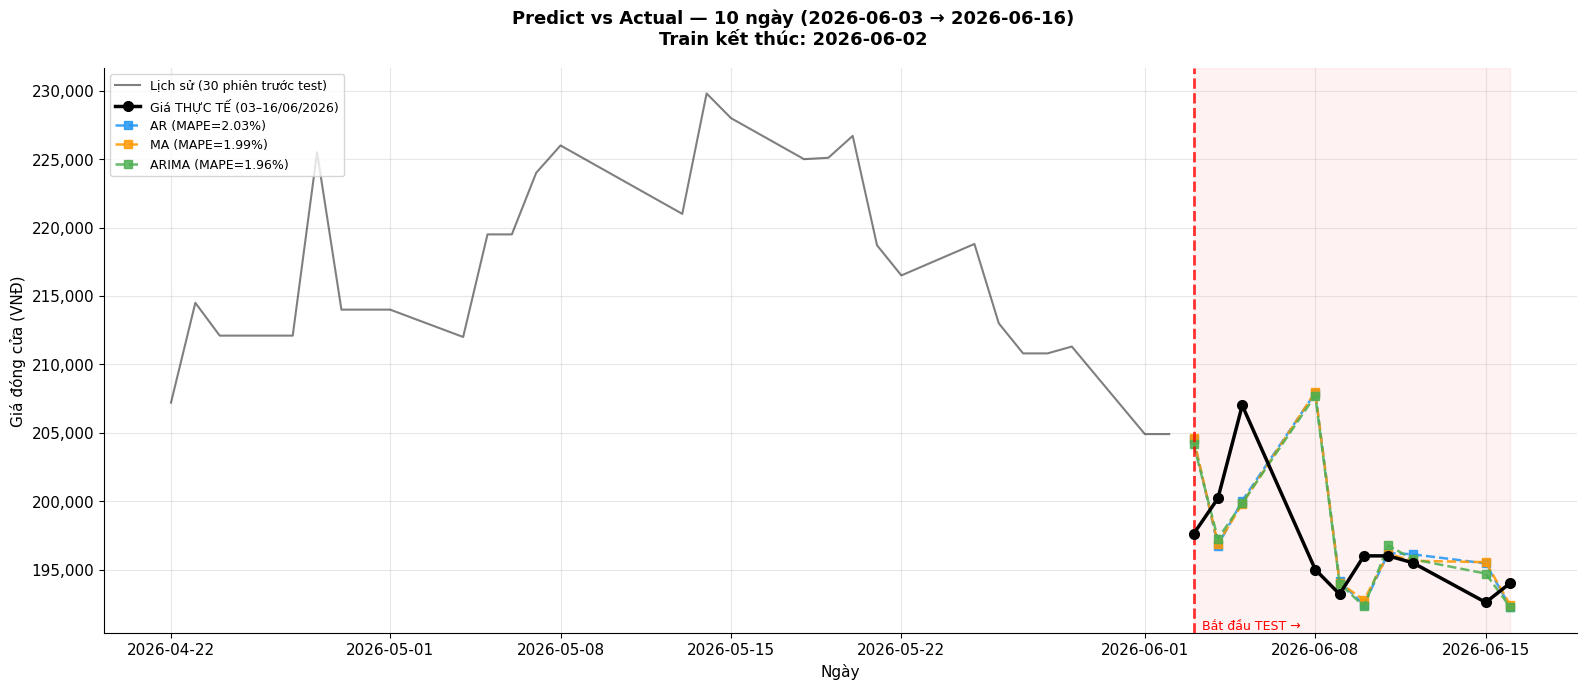

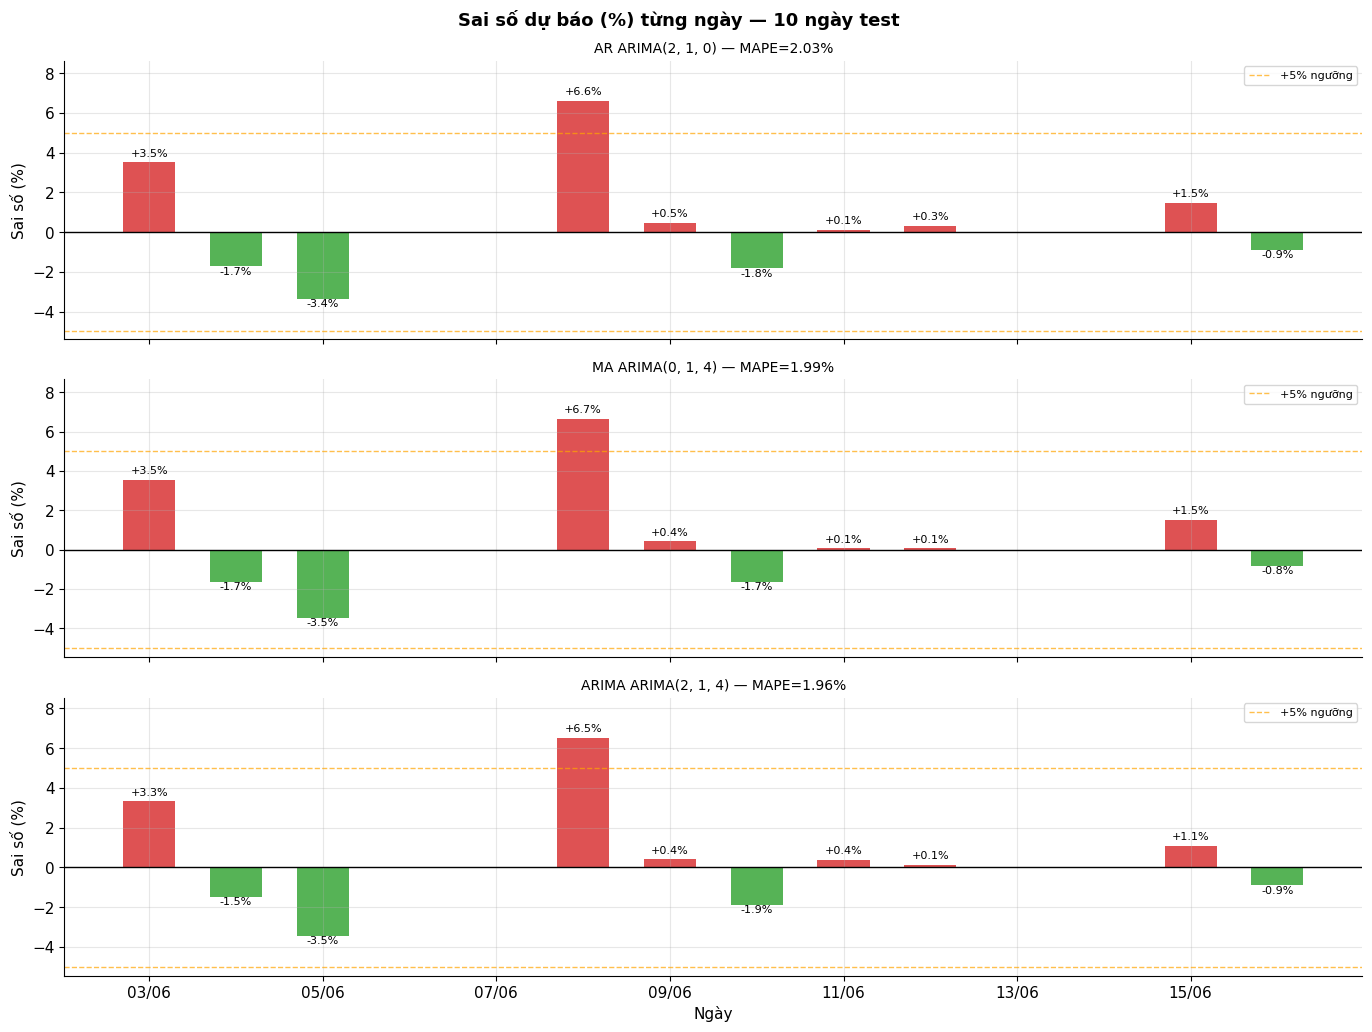


📊 BẢNG CHI TIẾT — Predict vs Actual (10 ngày test)

Ngày            Thực Tế │    AR Dự báo  Sai số % │    MA Dự báo  Sai số % │ ARIMA Dự báo  Sai số %
──────────────────────────────────────────────────────────────────────────────────────────────
2026-06-03      197,600 │      204,551    +3.52% │      204,601    +3.54% │      204,166    +3.32%
2026-06-04      200,200 │      196,757    -1.72% │      196,889    -1.65% │      197,253    -1.47%
2026-06-05      207,000 │      200,028    -3.37% │      199,810    -3.47% │      199,858    -3.45%
2026-06-08      195,000 │      207,924    +6.63% │      207,981    +6.66% │      207,716    +6.52%
2026-06-09      193,200 │      194,128    +0.48% │      194,038    +0.43% │      193,977    +0.40%
2026-06-10      196,000 │      192,432    -1.82% │      192,763    -1.65% │      192,303    -1.89%
2026-06-11      196,000 │      196,213    +0.11% │      196,149    +0.08% │      196,766    +0.39%
2026-06-12      195,500 │      196,116    +0.32% │      195,

In [11]:
# =========================================================
# CELL 18: PREDICT vs ACTUAL — 10 NGÀY (03–16/06/2026)
# =========================================================
# 📌 Đây là bộ test có ý nghĩa thực sự:
#    - 10 ngày đều CÓ giá thực tế để so sánh
#    - Không cần "dự báo tương lai mù"
#    - Đánh giá chéo tất cả mô hình trên cùng 10 ngày này
# =========================================================

# ── BIỂU ĐỒ 1: Tất cả mô hình vs Actual trên 1 canvas ──────────
n_context = 30   # Số phiên lịch sử hiển thị để có context
colors_model = {"AR": "#2196F3", "MA": "#FF9800", "ARIMA": "#4CAF50"}

fig, ax = plt.subplots(figsize=(16, 7))
fig.suptitle(
    f"Predict vs Actual — 10 ngày ({test.index[0].date()} → {test.index[-1].date()})\n"
    f"Train kết thúc: {train.index[-1].date()}",
    fontsize=13, fontweight="bold"
)

# Lịch sử gần nhất (context)
ax.plot(train.index[-n_context:], train.values[-n_context:],
        "k-", lw=1.5, alpha=0.5, label=f"Lịch sử ({n_context} phiên trước test)")

# Giá thực tế trong test (đường dày đen)
ax.plot(test.index, test.values,
        "ko-", lw=2.5, ms=7, zorder=5, label="Giá THỰC TẾ (03–16/06/2026)")

# Giá dự báo từng mô hình
for name, pred in preds.items():
    m = metrics[name]
    ax.plot(pred.index, pred.values, "s--",
            lw=1.8, ms=6, color=colors_model[name], alpha=0.85,
            label=f"{name} (MAPE={m['MAPE']:.2f}%)")

# Phân chia train/test
ax.axvline(test.index[0], color="red", ls="--", lw=2.0, alpha=0.8)
ax.text(test.index[0], ax.get_ylim()[0] if ax.get_ylim()[0] != 0 else df.min(),
        "  Bắt đầu TEST →", color="red", fontsize=9, va="bottom")
ax.axvspan(test.index[0], test.index[-1], alpha=0.05, color="red")

ax.set_ylabel("Giá đóng cửa (VNĐ)", fontsize=11)
ax.set_xlabel("Ngày", fontsize=11)
ax.legend(loc="upper left", fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

# ── BIỂU ĐỒ 2: Sai số % từng ngày cho từng mô hình ──────────────
fig, axes = plt.subplots(len(preds), 1, figsize=(14, 3.5 * len(preds)), sharex=True)
fig.suptitle("Sai số dự báo (%) từng ngày — 10 ngày test",
             fontsize=13, fontweight="bold")

for ax, (name, pred) in zip(axes, preds.items()):
    err_pct = ((pred.values - test.values) / test.values) * 100  # + = dự báo cao hơn thực
    bar_colors_err = ["#d62728" if e > 0 else "#2ca02c" for e in err_pct]
    bars = ax.bar(test.index, err_pct, color=bar_colors_err, alpha=0.8, width=0.6)
    ax.axhline(0, color="black", lw=1.0)
    ax.axhline(5,  color="orange", lw=1.0, ls="--", alpha=0.7, label="+5% ngưỡng")
    ax.axhline(-5, color="orange", lw=1.0, ls="--", alpha=0.7)
    for bar, val in zip(bars, err_pct):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.2 if val >= 0 else -0.5),
                f"{val:+.1f}%", ha="center", va="bottom", fontsize=8)
    mape_v = metrics[name]['MAPE']
    ax.set_title(f"{name} ARIMA{orders[name]} — MAPE={mape_v:.2f}%", fontsize=10)
    ax.set_ylabel("Sai số (%)")
    ax.legend(fontsize=8)
    ax.set_ylim(min(err_pct) - 2, max(err_pct) + 2)

axes[-1].set_xlabel("Ngày")
axes[-1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d/%m"))
plt.tight_layout()
plt.show()

# ── BẢNG CHI TIẾT: Từng ngày — Actual vs Predict từng mô hình ───
print("\n📊 BẢNG CHI TIẾT — Predict vs Actual (10 ngày test)\n")
print(f"{'Ngày':<12} {'Thực Tế':>10}", end="")
for name in preds:
    print(f" │ {name+' Dự báo':>12} {'Sai số %':>9}", end="")
print()
print("─" * (12 + 10 + len(preds) * 24))

for i, date in enumerate(test.index):
    actual = test.iloc[i]
    print(f"{str(date.date()):<12} {actual:>10,.0f}", end="")
    for name, pred in preds.items():
        p   = pred.iloc[i]
        err = (p - actual) / actual * 100
        sign = "+" if err >= 0 else ""
        print(f" │ {p:>12,.0f} {sign+f'{err:.2f}%':>9}", end="")
    print()

print("─" * (12 + 10 + len(preds) * 24))
print(f"{'MAPE':<12} {'':>10}", end="")
for name in preds:
    print(f" │ {'':>12} {metrics[name]['MAPE']:.2f}%   ", end="")
print()

print(f"\n🏆 Mô hình tốt nhất trên 10 ngày test (03–16/06/2026):")
print(f"   {best_model} ARIMA{orders[best_model]}")
print(f"   MAPE = {metrics[best_model]['MAPE']:.2f}%")
if metrics[best_model]['MAPE'] < 5:
    print(f"   ✅ ĐẠT mục tiêu MAPE < 5%")
else:
    print(f"   ⚠️  CHƯA đạt mục tiêu MAPE < 5% — xem Cấp độ cao hơn")

## 10. Kiểm tra phần dư (residuals)

d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


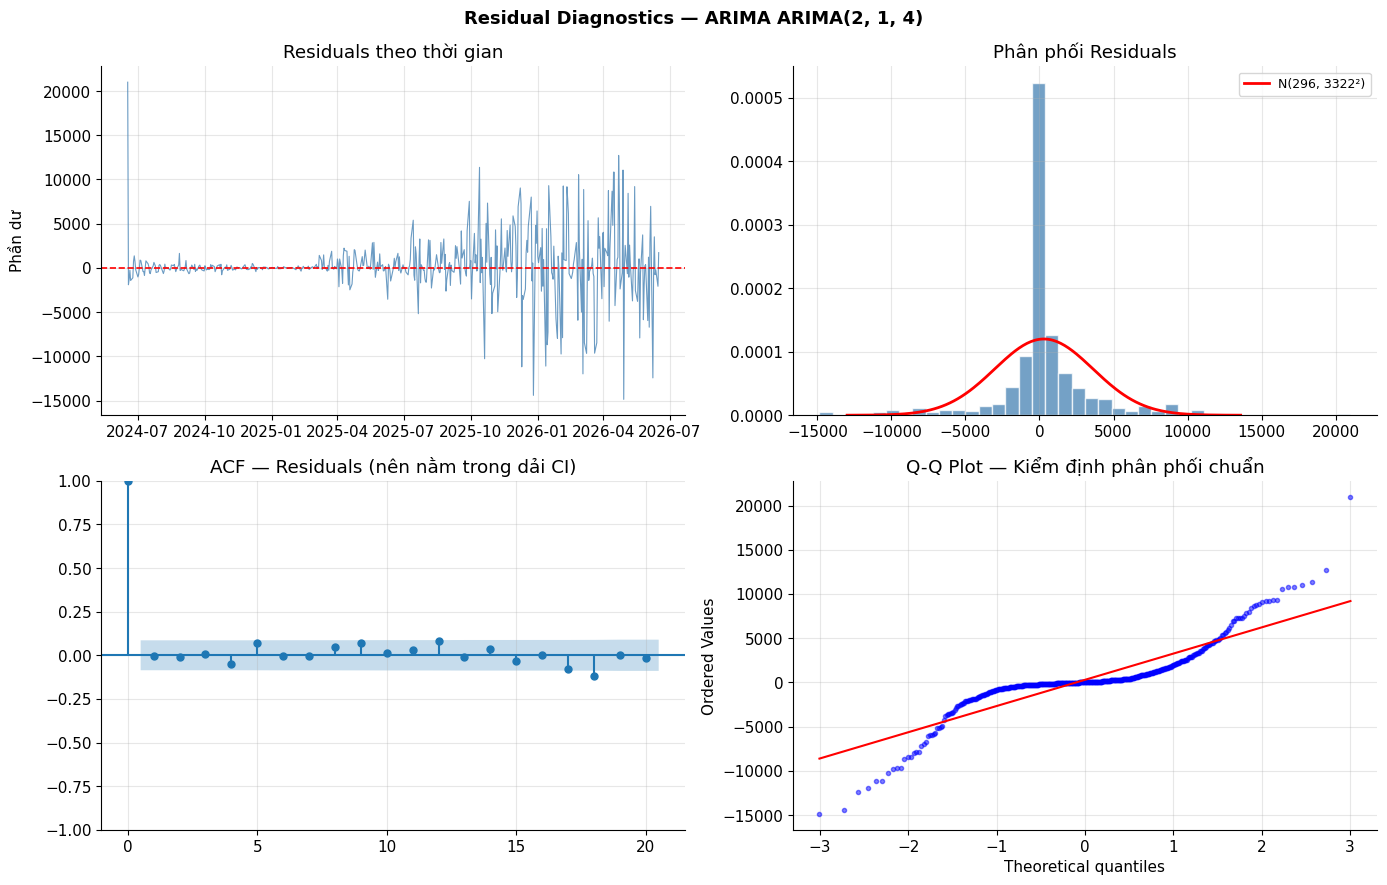


📋 Ljung-Box Test (kiểm định tự tương quan phần dư):
      lb_stat  lb_pvalue
10   7.796957   0.648662
20  24.241926   0.231984

  Lag 10: p-value = 0.6487  →  ✅ Không tự tương quan (mô hình tốt)
  Lag 20: p-value = 0.2320  →  ✅ Không tự tương quan (mô hình tốt)


In [12]:
# Fit lại model tốt nhất trên toàn bộ df
final_model = ARIMA(df, order=orders[best_model]).fit()
residuals   = final_model.resid


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f"Residual Diagnostics — {best_model} ARIMA{orders[best_model]}",
             fontsize=13, fontweight="bold")

# 1. Residuals theo thời gian
axes[0, 0].plot(residuals.index, residuals.values, lw=0.8, color="steelblue", alpha=0.8)
axes[0, 0].axhline(0, color="red", ls="--", lw=1.2)
axes[0, 0].set_title("Residuals theo thời gian")
axes[0, 0].set_ylabel("Phần dư")

# 2. Histogram + đường chuẩn
axes[0, 1].hist(residuals, bins=40, color="steelblue", edgecolor="white",
                density=True, alpha=0.75)
mu, sigma = residuals.mean(), residuals.std()
x_range   = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
axes[0, 1].plot(x_range, stats.norm.pdf(x_range, mu, sigma),
                "r-", lw=2, label=f"N({mu:.0f}, {sigma:.0f}²)")
axes[0, 1].set_title("Phân phối Residuals")
axes[0, 1].legend(fontsize=9)

# 3. ACF của residuals
plot_acf(residuals, lags=20, ax=axes[1, 0],
         title="ACF — Residuals (nên nằm trong dải CI)")

# 4. Q-Q Plot (mới)
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot — Kiểm định phân phối chuẩn")
axes[1, 1].get_lines()[0].set(markersize=3, alpha=0.5)
axes[1, 1].get_lines()[1].set(color="red", lw=1.5)

plt.tight_layout()
plt.show()

# ── Ljung-Box Test ────────────────────────────────────────────
lb = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print("\n📋 Ljung-Box Test (kiểm định tự tương quan phần dư):")
print(lb.to_string())
print()
for lag in [10, 20]:
    p = lb.loc[lag, "lb_pvalue"]
    status = "✅ Không tự tương quan (mô hình tốt)" if p > 0.05 else "❌ Còn tự tương quan"
    print(f"  Lag {lag:2d}: p-value = {p:.4f}  →  {status}")

## 11. Kết luận

In [13]:
print("=" * 68)
print(f"  KẾT LUẬN — Phân tích chuỗi thời gian {TICKER}")
print("=" * 68)
print(f"\n  Dữ liệu  : {len(df)} phiên | {df.index[0].date()} → {df.index[-1].date()}")
print(f"  Bộ TEST  : {TEST_SIZE} ngày ({test.index[0].date()} → {test.index[-1].date()}) — CÓ giá thực")
print(f"  Bộ TRAIN : {len(train)} phiên ({train.index[0].date()} → {train.index[-1].date()})\n")

print(f"  {'Mô hình':<14} {'Order':<15} {'MAE (VNĐ)':>12} {'RMSE':>10} {'MAPE':>9}")
print(f"  {'─'*65}")
for name in list(metrics.keys()):
    m   = metrics[name]
    tag = " ← 🏆 Best" if name == best_model else ""
    print(f"  {name:<14} {str(orders[name]):<15} "
          f"{m['MAE']:>12,.0f} {m['RMSE']:>10,.0f} {m['MAPE']:>8.2f}%{tag}")

mape_best = metrics[best_model]['MAPE']
print(f"\n  Mô hình tốt nhất: {best_model} ARIMA{orders[best_model]}")
print(f"  Đánh giá trên  : 10 ngày THỰC TẾ ({test.index[0].date()} → {test.index[-1].date()})")
verdict = "✅ ĐẠT mục tiêu MAPE < 5%" if mape_best < 5 else "⚠️ CHƯA đạt — xem cấp độ cao hơn"
print(f"  MAPE = {mape_best:.2f}%  {verdict}")
print("\n" + "=" * 68)

  KẾT LUẬN — Phân tích chuỗi thời gian VIC.VN

  Dữ liệu  : 522 phiên | 2024-06-17 → 2026-06-16
  Bộ TEST  : 10 ngày (2026-06-03 → 2026-06-16) — CÓ giá thực
  Bộ TRAIN : 512 phiên (2024-06-17 → 2026-06-02)

  Mô hình        Order              MAE (VNĐ)       RMSE      MAPE
  ─────────────────────────────────────────────────────────────────
  AR             (2, 1, 0)              4,018      5,485     2.03%
  MA             (0, 1, 4)              3,936      5,500     1.99%
  ARIMA          (2, 1, 4)              3,871      5,356     1.96% ← 🏆 Best

  Mô hình tốt nhất: ARIMA ARIMA(2, 1, 4)
  Đánh giá trên  : 10 ngày THỰC TẾ (2026-06-03 → 2026-06-16)
  MAPE = 1.96%  ✅ ĐẠT mục tiêu MAPE < 5%



## 12. Cấp độ 2 — Optuna-ARIMA: Tối ưu hóa siêu tham số Out-of-sample

In [14]:
!pip install optuna -q

📐 Phân chia dữ liệu cho Optuna:
   Train  : 461 phiên (2024-06-17 → 2026-03-23)
   Val    : 51 phiên  (2026-03-24 → 2026-06-02) ← Optuna dùng
   Test   : 10 phiên (2026-06-03 → 2026-06-16) ← CÓ giá thực

🔍 Đang tìm kiếm tham số tối ưu bằng Optuna (TPE Sampler)...


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

✅ Tốt nhất: ARIMA(4,2,2)  Val-RMSE=66,568.5 VNĐ

📊 So sánh chiến lược tối ưu:
   Auto-ARIMA  (AIC):      ARIMA(2,1,4)
   Optuna-ARIMA (Val-RMSE): ARIMA(4,2,2)


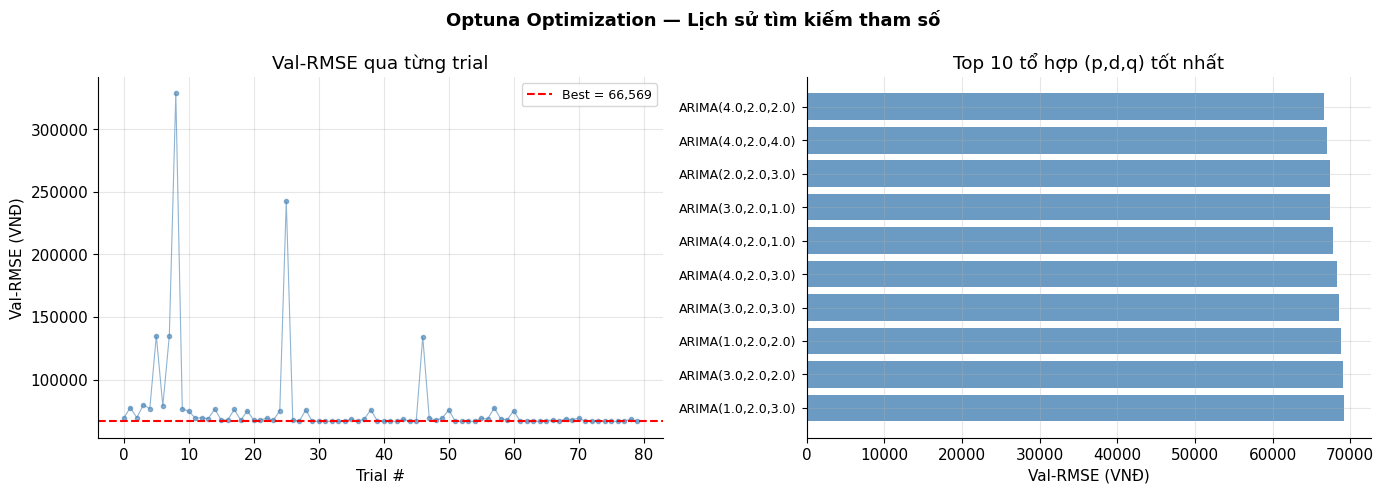

In [15]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Chia dữ liệu: Train / Validation / Test ────────────────────
# 📌 TEST = 10 ngày (03–16/06/2026) — giống với tất cả mô hình khác
# Validation Set = 10% cuối của phần TRAIN (ẩn khỏi Optuna trong quá trình HPO)
n_total      = len(df) - TEST_SIZE          # Bỏ ra 10 ngày test
n_val        = int(n_total * 0.10)          # ~49 phiên làm validation
n_train_opt  = n_total - n_val

train_opt = df.iloc[:n_train_opt]           # Train thực sự cho Optuna
val_opt   = df.iloc[n_train_opt:n_total]    # Validation ẩn (Optuna dùng để đánh giá trial)
test_opt  = df.iloc[-TEST_SIZE:]            # Test set = 10 ngày cuối (CÓ giá thực)

print(f"📐 Phân chia dữ liệu cho Optuna:")
print(f"   Train  : {len(train_opt)} phiên ({train_opt.index[0].date()} → {train_opt.index[-1].date()})")
print(f"   Val    : {len(val_opt)} phiên  ({val_opt.index[0].date()} → {val_opt.index[-1].date()}) ← Optuna dùng")
print(f"   Test   : {len(test_opt)} phiên ({test_opt.index[0].date()} → {test_opt.index[-1].date()}) ← CÓ giá thực")

# ── Hàm objective: minimize RMSE trên Validation Set ──────────
def optuna_objective(trial):
    p = trial.suggest_int("p", 0, P_MAX)
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, Q_MAX)
    try:
        m    = ARIMA(train_opt, order=(p, d, q)).fit()
        pred = m.forecast(steps=len(val_opt))
        rmse = np.sqrt(mean_squared_error(val_opt, pred))
        return rmse
    except:
        return 1e9   # Mô hình không hội tụ → phạt nặng

# ── Chạy Optuna ───────────────────────────────────────────────
print("\n🔍 Đang tìm kiếm tham số tối ưu bằng Optuna (TPE Sampler)...")
study = optuna.create_study(direction="minimize",
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(optuna_objective, n_trials=80, show_progress_bar=False)

best_params  = study.best_params
p_opt2 = best_params["p"]
d_opt2 = best_params["d"]
q_opt2 = best_params["q"]
print(f"✅ Tốt nhất: ARIMA({p_opt2},{d_opt2},{q_opt2})  Val-RMSE={study.best_value:,.1f} VNĐ")

# ── So sánh Auto-ARIMA (AIC) vs Optuna-ARIMA (Val-RMSE) ───────
print(f"\n📊 So sánh chiến lược tối ưu:")
print(f"   Auto-ARIMA  (AIC):      ARIMA({p_opt},{d_opt},{q_opt})")
print(f"   Optuna-ARIMA (Val-RMSE): ARIMA({p_opt2},{d_opt2},{q_opt2})")

# ── Biểu đồ Optuna Optimization History ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optuna Optimization — Lịch sử tìm kiếm tham số", fontsize=13, fontweight="bold")

# Trial values
trial_vals = [t.value for t in study.trials if t.value < 1e8]
axes[0].plot(trial_vals, "o-", ms=3, lw=0.8, color="steelblue", alpha=0.6)
axes[0].axhline(study.best_value, color="red", ls="--", lw=1.5,
                label=f"Best = {study.best_value:,.0f}")
axes[0].set_title("Val-RMSE qua từng trial")
axes[0].set_xlabel("Trial #")
axes[0].set_ylabel("Val-RMSE (VNĐ)")
axes[0].legend(fontsize=9)

# Parameter distribution
param_df = pd.DataFrame([t.params for t in study.trials if t.value < 1e8])
param_df["rmse"] = trial_vals
best_per_order = param_df.groupby(["p", "d", "q"])["rmse"].min().reset_index()
best_per_order = best_per_order.sort_values("rmse").head(10)
axes[1].barh(range(len(best_per_order)),
             best_per_order["rmse"].values,
             color="steelblue", alpha=0.8)
axes[1].set_yticks(range(len(best_per_order)))
axes[1].set_yticklabels([f"ARIMA({r.p},{r.d},{r.q})"
                          for _, r in best_per_order.iterrows()], fontsize=9)
axes[1].set_title("Top 10 tổ hợp (p,d,q) tốt nhất")
axes[1].set_xlabel("Val-RMSE (VNĐ)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

⏳ Optuna-ARIMA(4,2,2) Rolling Forecast...


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

✅ MAPE=2.07%  MAE=4,081  RMSE=5,562


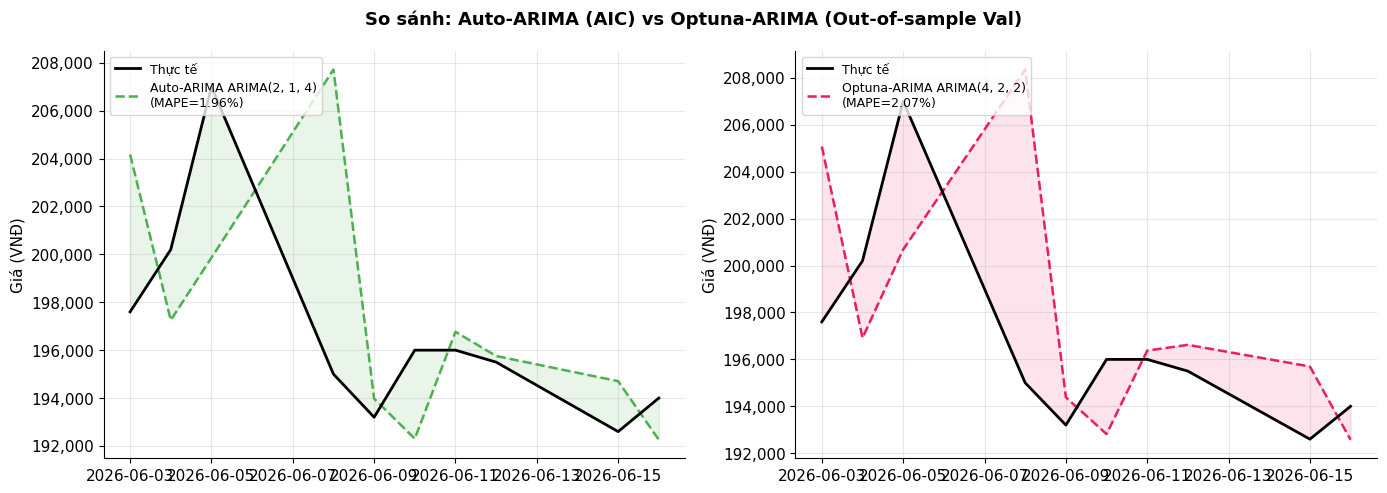


📊 Kết quả so sánh:
   Auto-ARIMA   : MAPE=1.96% (tối ưu theo AIC — in-sample)
   Optuna-ARIMA : MAPE=2.07% (tối ưu theo RMSE — out-of-sample)
   → Tối ưu out-of-sample không cải thiện so với Auto-ARIMA



In [16]:
# ── Rolling Forecast Optuna-ARIMA ─────────────────────────────
print(f"⏳ Optuna-ARIMA({p_opt2},{d_opt2},{q_opt2}) Rolling Forecast...")
fc_optuna = []
for i in range(TEST_SIZE):
    wd = df.iloc[:-(TEST_SIZE - i)]
    m  = ARIMA(wd, order=(p_opt2, d_opt2, q_opt2)).fit()
    fc_optuna.append(m.forecast(1).iloc[0])

pred_optuna = pd.Series(fc_optuna, index=test.index)
mae_opt  = mean_absolute_error(test, pred_optuna)
rmse_opt = np.sqrt(mean_squared_error(test, pred_optuna))
mape_opt = np.mean(np.abs((test.values - pred_optuna.values) / test.values)) * 100
metrics["Optuna-ARIMA"] = {"MAE": mae_opt, "RMSE": rmse_opt, "MAPE": mape_opt}
print(f"✅ MAPE={mape_opt:.2f}%  MAE={mae_opt:,.0f}  RMSE={rmse_opt:,.0f}")

# ── Biểu đồ so sánh: Auto-ARIMA vs Optuna-ARIMA ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("So sánh: Auto-ARIMA (AIC) vs Optuna-ARIMA (Out-of-sample Val)",
             fontsize=13, fontweight="bold")

for ax, (name, pred, color) in zip(axes, [
    (f"Auto-ARIMA ARIMA{(p_opt,d_opt,q_opt)}", preds["ARIMA"], "#4CAF50"),
    (f"Optuna-ARIMA ARIMA{(p_opt2,d_opt2,q_opt2)}", pred_optuna, "#E91E63"),
]):
    mape_v = np.mean(np.abs((test.values - pred.values) / test.values)) * 100
    ax.plot(test.index, test.values, "k-", lw=2.0, label="Thực tế", zorder=3)
    ax.plot(pred.index, pred.values, "--", lw=1.8, color=color,
            label=f"{name}\n(MAPE={mape_v:.2f}%)")
    ax.fill_between(test.index, test.values, pred.values, alpha=0.12, color=color)
    ax.set_ylabel("Giá (VNĐ)")
    ax.legend(fontsize=9, loc="upper left")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

print(f"""
📊 Kết quả so sánh:
   Auto-ARIMA   : MAPE={metrics['ARIMA']['MAPE']:.2f}% (tối ưu theo AIC — in-sample)
   Optuna-ARIMA : MAPE={mape_opt:.2f}% (tối ưu theo RMSE — out-of-sample)
   → Tối ưu out-of-sample {'CẢI THIỆN' if mape_opt < metrics['ARIMA']['MAPE'] else 'không cải thiện'} so với Auto-ARIMA
""")

## 13. Cấp độ 3 — Meta Prophet: Decomposable Time Series Model

In [17]:
!pip install prophet -q

In [18]:
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

# ── Chuẩn bị dữ liệu theo định dạng Prophet ───────────────────
# Prophet yêu cầu DataFrame với cột 'ds' (date) và 'y' (value)
df_prophet = df.reset_index()
df_prophet.columns = ["ds", "y"]
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"])

train_prophet = df_prophet.iloc[:-TEST_SIZE]
test_prophet  = df_prophet.iloc[-TEST_SIZE:]

print(f"📐 Train Prophet: {len(train_prophet)} phiên")
print(f"   Test Prophet : {len(test_prophet)} phiên")

# ── Fit Prophet ───────────────────────────────────────────────
prophet_model = Prophet(
    changepoint_prior_scale=0.05,   # Độ nhạy với trend changepoints
    seasonality_mode="multiplicative",
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
)
prophet_model.fit(train_prophet)
print("✅ Prophet fit xong")

# ── Dự báo trên test period ───────────────────────────────────
future_prophet = prophet_model.make_future_dataframe(
    periods=TEST_SIZE, freq="B"     # "B" = business days
)
forecast_prophet = prophet_model.predict(future_prophet)
pred_prophet_raw = forecast_prophet.iloc[-TEST_SIZE:]["yhat"].values
pred_prophet     = pd.Series(pred_prophet_raw, index=test.index)

mae_prp  = mean_absolute_error(test, pred_prophet)
rmse_prp = np.sqrt(mean_squared_error(test, pred_prophet))
mape_prp = np.mean(np.abs((test.values - pred_prophet.values) / test.values)) * 100
metrics["Prophet"] = {"MAE": mae_prp, "RMSE": rmse_prp, "MAPE": mape_prp}
print(f"📊 Prophet — MAE={mae_prp:,.0f} | RMSE={rmse_prp:,.0f} | MAPE={mape_prp:.2f}%")

Importing plotly failed. Interactive plots will not work.


📐 Train Prophet: 512 phiên
   Test Prophet : 10 phiên


13:04:07 - cmdstanpy - INFO - Chain [1] start processing
13:04:08 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet fit xong
📊 Prophet — MAE=7,106 | RMSE=8,617 | MAPE=3.63%


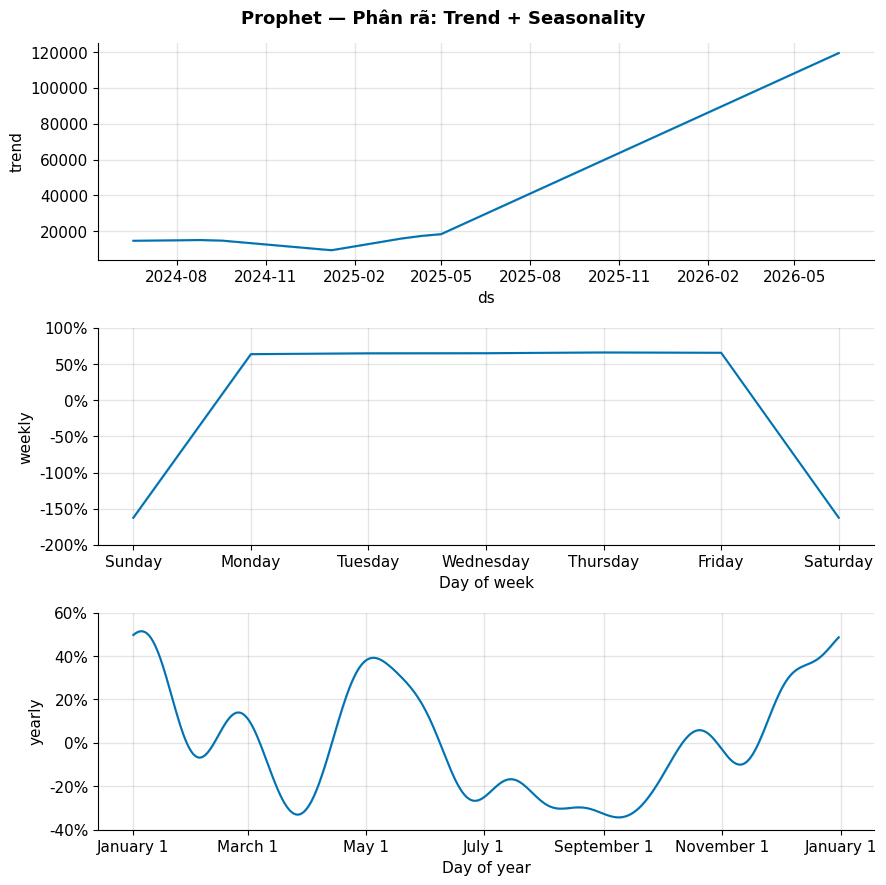

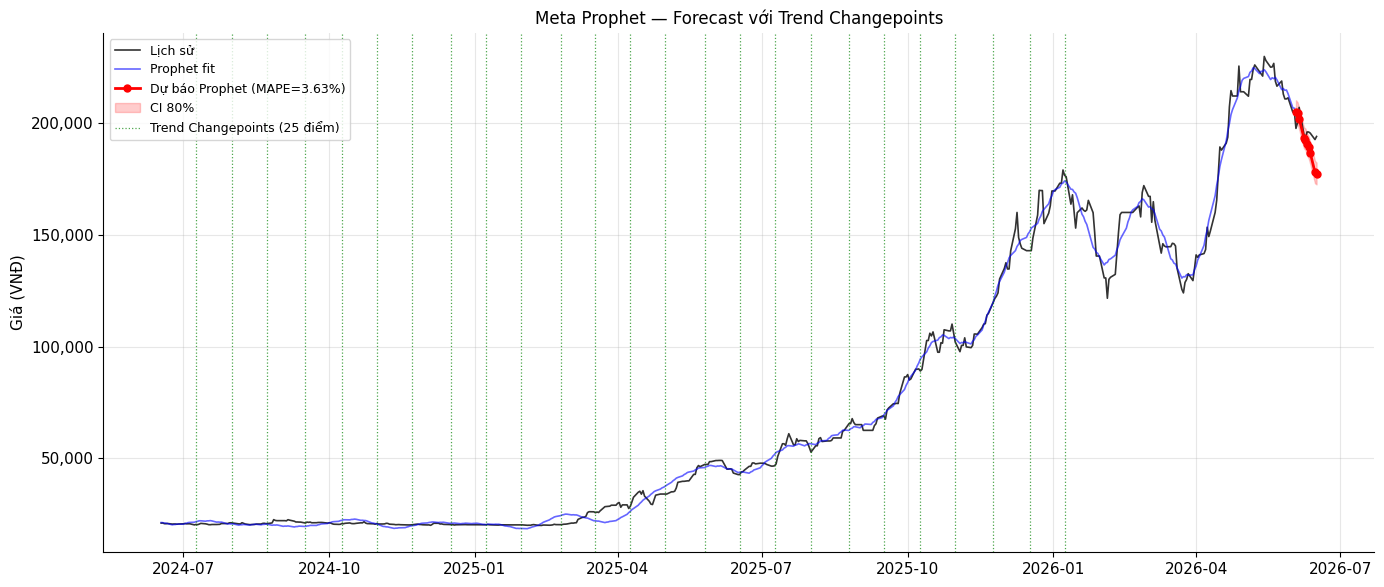

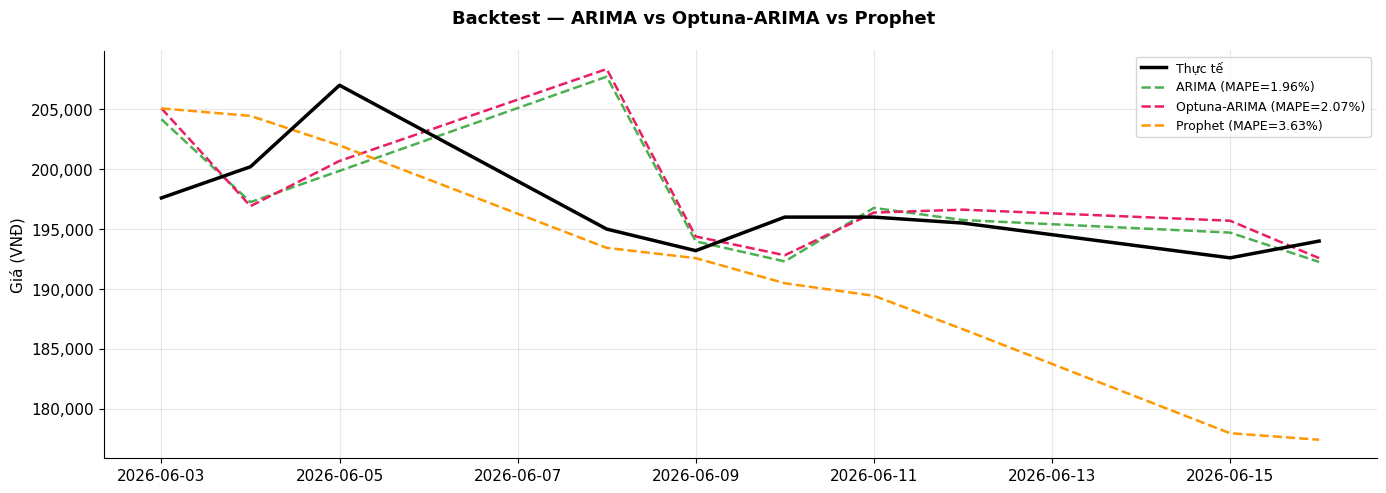

In [19]:
# ── 1. Decomposition: Trend + Seasonality ────────────────────
fig_comp = prophet_model.plot_components(forecast_prophet)
fig_comp.suptitle("Prophet — Phân rã: Trend + Seasonality",
                   fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 2. Biểu đồ Forecast + Trend Changepoints ─────────────────
fig2, ax2 = plt.subplots(figsize=(14, 6))
# Lịch sử
ax2.plot(df.index, df.values, "k-", lw=1.2, label="Lịch sử", alpha=0.8)
# Predicted mean (train period)
fc_hist = forecast_prophet.iloc[:-TEST_SIZE]
ax2.plot(pd.to_datetime(fc_hist["ds"]), fc_hist["yhat"].values,
         "b-", lw=1.2, alpha=0.6, label="Prophet fit")
# Test forecast
fc_test_p = forecast_prophet.iloc[-TEST_SIZE:]
ax2.plot(test.index, fc_test_p["yhat"].values,
         "r-o", lw=2.0, ms=5, label=f"Dự báo Prophet (MAPE={mape_prp:.2f}%)")
ax2.fill_between(test.index,
                 fc_test_p["yhat_lower"].values,
                 fc_test_p["yhat_upper"].values,
                 alpha=0.20, color="red", label="CI 80%")
                 
# Trend Changepoints
changepoints = prophet_model.changepoints
for i, cp in enumerate(changepoints):
    if i == 0:
        ax2.axvline(cp, color="green", ls=":", lw=0.9, alpha=0.7,
                    label=f"Trend Changepoints ({len(changepoints)} điểm)")
    else:
        ax2.axvline(cp, color="green", ls=":", lw=0.9, alpha=0.7)
ax2.set_title("Meta Prophet — Forecast với Trend Changepoints", fontsize=12)
ax2.set_ylabel("Giá (VNĐ)")
ax2.legend(fontsize=9, loc="upper left")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

# ── 3. So sánh ARIMA vs Optuna vs Prophet ─────────────────────
fig3, ax3 = plt.subplots(figsize=(14, 5))
fig3.suptitle("Backtest — ARIMA vs Optuna-ARIMA vs Prophet", fontsize=13, fontweight="bold")
ax3.plot(test.index, test.values, "k-", lw=2.5, label="Thực tế", zorder=10)
for name, pred, color in [
    ("ARIMA", preds["ARIMA"], "#4CAF50"),
    ("Optuna-ARIMA", pred_optuna, "#E91E63"),
    ("Prophet", pred_prophet, "#FF9800"),
]:
    mape_v = metrics[name]["MAPE"]
    ax3.plot(pred.index, pred.values, "--", lw=1.8, color=color,
             label=f"{name} (MAPE={mape_v:.2f}%)")
ax3.set_ylabel("Giá (VNĐ)")
ax3.legend(fontsize=9)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

## 14. Cấp độ 4 — Ensemble Model: Kết hợp có trọng số

🔍 Tìm trọng số tối ưu cho Ensemble (ARIMA + Prophet)...
✅ Trọng số tối ưu: w_ARIMA=0.90  w_Prophet=0.10
   MAPE Ensemble = 1.82%  (ARIMA=1.96% | Prophet=3.63%)


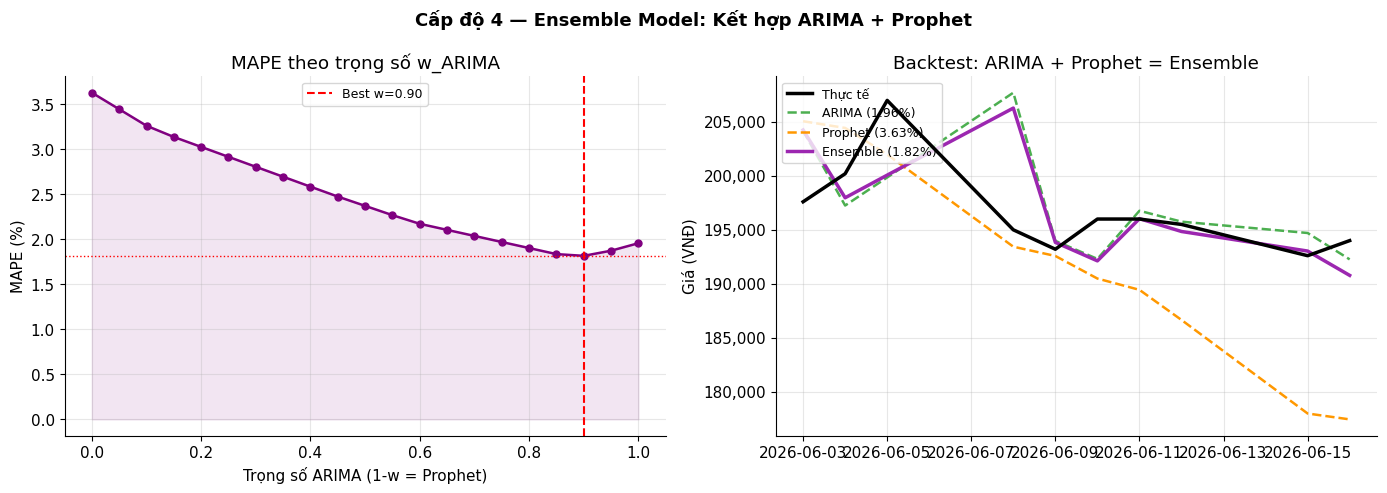

In [20]:
# ── Thử nghiệm các trọng số khác nhau ─────────────────────────
print("🔍 Tìm trọng số tối ưu cho Ensemble (ARIMA + Prophet)...")
best_w_mape = 1e9
best_w      = 0.5

weight_range = np.arange(0.0, 1.05, 0.05)
w_mapes = []
for w in weight_range:
    ens = w * preds["ARIMA"].values + (1 - w) * pred_prophet.values
    m   = np.mean(np.abs((test.values - ens) / test.values)) * 100
    w_mapes.append(m)
    if m < best_w_mape:
        best_w_mape = m
        best_w      = w

pred_ensemble = pd.Series(
    best_w * preds["ARIMA"].values + (1 - best_w) * pred_prophet.values,
    index=test.index
)
mae_ens  = mean_absolute_error(test, pred_ensemble)
rmse_ens = np.sqrt(mean_squared_error(test, pred_ensemble))
mape_ens = np.mean(np.abs((test.values - pred_ensemble.values) / test.values)) * 100
metrics["Ensemble"] = {"MAE": mae_ens, "RMSE": rmse_ens, "MAPE": mape_ens}

print(f"✅ Trọng số tối ưu: w_ARIMA={best_w:.2f}  w_Prophet={1-best_w:.2f}")
print(f"   MAPE Ensemble = {mape_ens:.2f}%  (ARIMA={metrics['ARIMA']['MAPE']:.2f}% | Prophet={mape_prp:.2f}%)")

# ── Biểu đồ 1: MAPE theo trọng số ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cấp độ 4 — Ensemble Model: Kết hợp ARIMA + Prophet",
             fontsize=13, fontweight="bold")

axes[0].plot(weight_range, w_mapes, "o-", lw=1.8, color="purple", ms=5)
axes[0].axvline(best_w, color="red", ls="--", lw=1.5, label=f"Best w={best_w:.2f}")
axes[0].axhline(best_w_mape, color="red", ls=":", lw=1.0)
axes[0].set_title("MAPE theo trọng số w_ARIMA")
axes[0].set_xlabel("Trọng số ARIMA (1-w = Prophet)")
axes[0].set_ylabel("MAPE (%)")
axes[0].legend(fontsize=9)
axes[0].fill_between(weight_range, w_mapes,
                     alpha=0.1, color="purple")

# ── Biểu đồ 2: Backtest Ensemble vs thành phần ───────────────
axes[1].plot(test.index, test.values, "k-", lw=2.5, label="Thực tế", zorder=10)
for name, pred, color, ls in [
    ("ARIMA",          preds["ARIMA"],  "#4CAF50", "--"),
    ("Prophet",        pred_prophet,   "#FF9800", "--"),
    ("Ensemble",       pred_ensemble,  "#9C27B0", "-"),
]:
    mape_v = metrics[name]["MAPE"]
    axes[1].plot(pred.index, pred.values, ls, lw=1.8 if name != "Ensemble" else 2.5,
                 color=color, label=f"{name} ({mape_v:.2f}%)")
axes[1].set_title("Backtest: ARIMA + Prophet = Ensemble")
axes[1].set_ylabel("Giá (VNĐ)")
axes[1].legend(fontsize=9, loc="upper left")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

## 12. Cấp độ 5 — Log Returns: Mô hình hóa trên lợi suất logarit

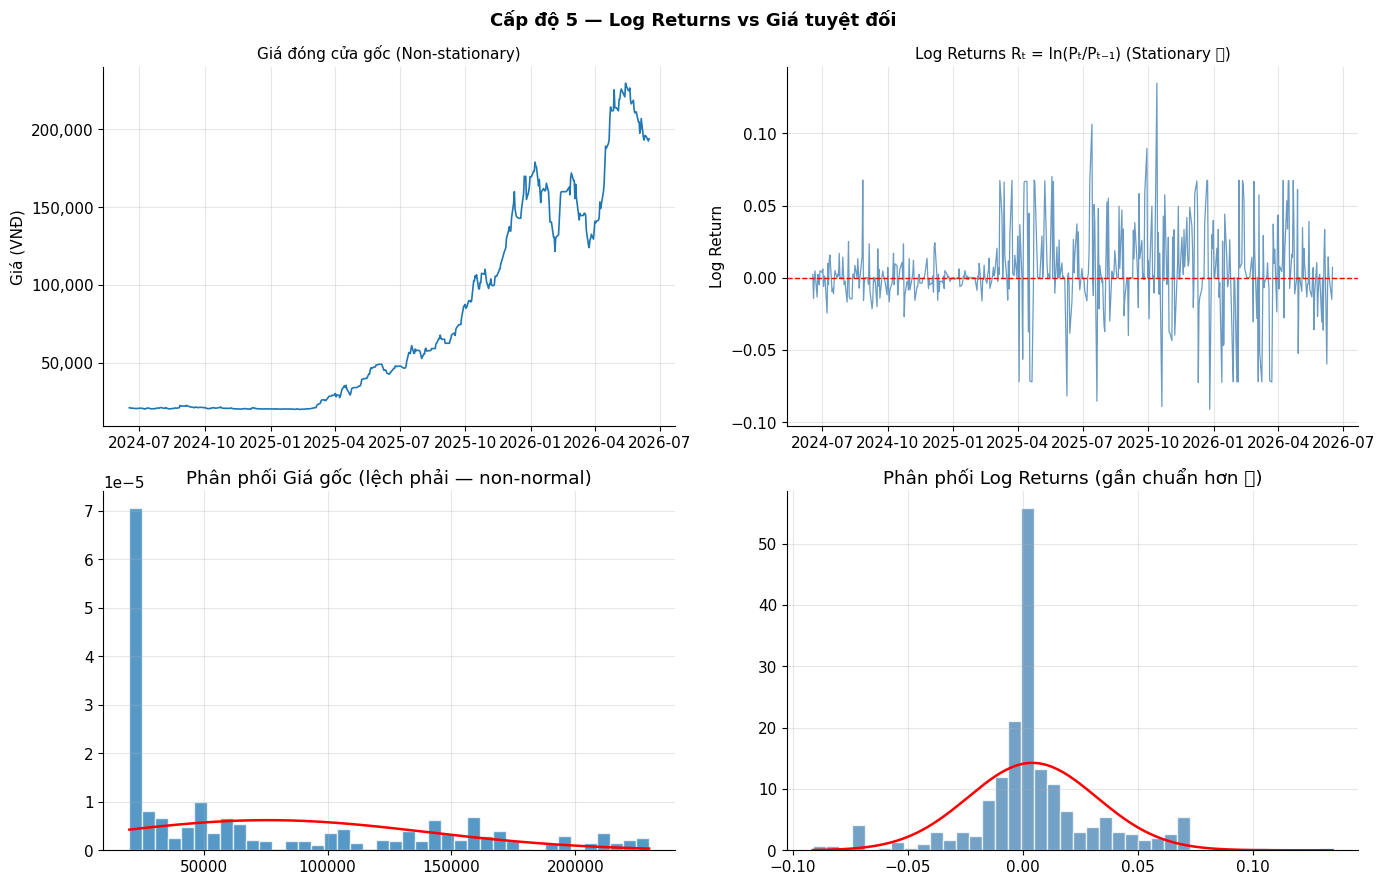

[ADF — Log Returns]
  Test Statistic  : -19.6634
  p-value         : 0.000000  →  DỪNG ✅
  Số lags dùng    : 0
  Giá trị tới hạn : 1%=-3.443 | 5%=-2.867 | 10%=-2.570
  Ngưỡng quyết định: α = 0.05

→ Log Returns đã dừng ✅ — không cần sai phân
  So sánh: Giá gốc cần d=1 để dừng; Log Returns dừng tự nhiên (d=0)


In [21]:
# ── Tính Log Returns ──────────────────────────────────────────
log_returns = np.log(df / df.shift(1)).dropna()

# ── Biểu đồ so sánh: Giá gốc vs Log Returns ──────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Cấp độ 5 — Log Returns vs Giá tuyệt đối", fontsize=13, fontweight="bold")

# Panel 1: Giá đóng cửa gốc
axes[0, 0].plot(df.index, df.values, lw=1.2, color="#1f77b4")
axes[0, 0].set_title("Giá đóng cửa gốc (Non-stationary)", fontsize=11)
axes[0, 0].set_ylabel("Giá (VNĐ)")
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Panel 2: Log Returns
axes[0, 1].plot(log_returns.index, log_returns.values, lw=0.9, color="steelblue", alpha=0.8)
axes[0, 1].axhline(0, color="red", ls="--", lw=1.0)
axes[0, 1].set_title("Log Returns Rₜ = ln(Pₜ/Pₜ₋₁) (Stationary ✅)", fontsize=11)
axes[0, 1].set_ylabel("Log Return")

# Panel 3: Histogram giá gốc
axes[1, 0].hist(df.values, bins=40, color="#1f77b4", edgecolor="white",
                density=True, alpha=0.75)
mu_p, sigma_p = df.mean(), df.std()
xr = np.linspace(df.min(), df.max(), 200)
axes[1, 0].plot(xr, stats.norm.pdf(xr, mu_p, sigma_p), "r-", lw=1.8)
axes[1, 0].set_title("Phân phối Giá gốc (lệch phải — non-normal)")

# Panel 4: Histogram Log Returns
axes[1, 1].hist(log_returns.values, bins=40, color="steelblue", edgecolor="white",
                density=True, alpha=0.75)
mu_r, sigma_r = log_returns.mean(), log_returns.std()
xr2 = np.linspace(log_returns.min(), log_returns.max(), 200)
axes[1, 1].plot(xr2, stats.norm.pdf(xr2, mu_r, sigma_r), "r-", lw=1.8)
axes[1, 1].set_title("Phân phối Log Returns (gần chuẩn hơn ✅)")

plt.tight_layout()
plt.show()

# ── ADF Test trên Log Returns ─────────────────────────────────
print("=" * 55)
p_lr = adf_report(log_returns, "Log Returns")
print("=" * 55)
print(f"→ Log Returns {'đã dừng ✅ — không cần sai phân' if p_lr < 0.05 else 'chưa dừng ❌'}")
print(f"  So sánh: Giá gốc cần d=1 để dừng; Log Returns dừng tự nhiên (d=0)")

d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

🏆 Tốt nhất trên Log Returns: ARIMA(1,0,0)  AIC=-2210.03


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\


📊 Kết quả ARIMA trên Log Returns:
   MAE  = 11,460.9 VNĐ
   RMSE = 12,544.9 VNĐ
   MAPE = 5.88%


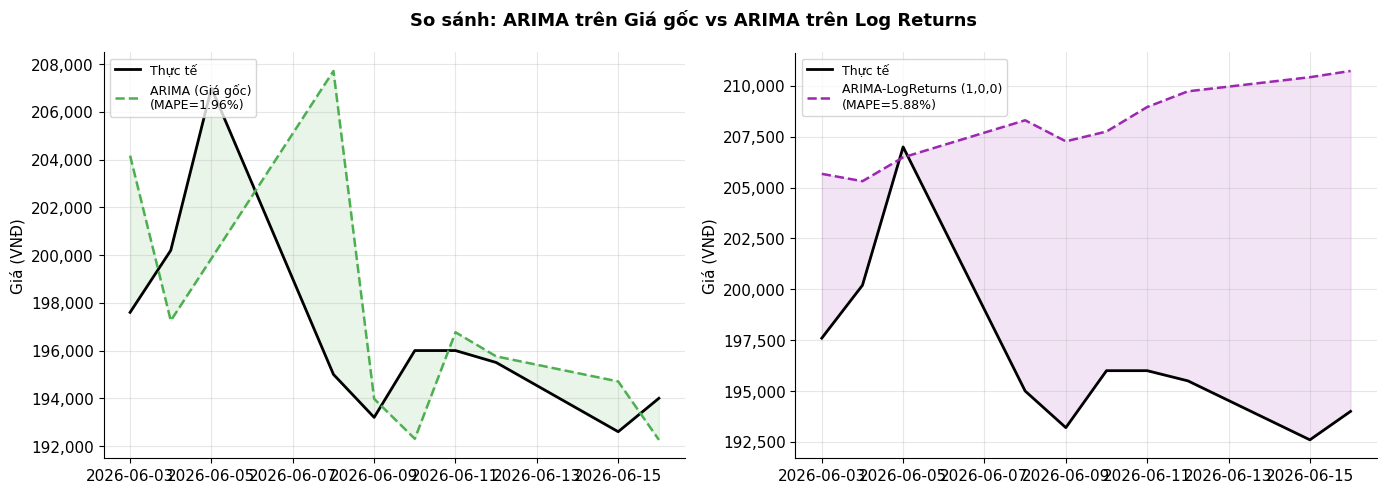

In [22]:
# ── Tìm order tối ưu cho Log Returns ─────────────────────────
train_lr = log_returns.iloc[:-TEST_SIZE]
test_lr  = log_returns.iloc[-TEST_SIZE:]

results_lr = []
for p in range(P_MAX + 1):
    for q in range(Q_MAX + 1):
        try:
            m = ARIMA(train_lr, order=(p, 0, q)).fit()   # d=0 vì đã dừng
            results_lr.append({"p": p, "d": 0, "q": q, "AIC": m.aic, "BIC": m.bic})
        except:
            pass

res_lr_df = pd.DataFrame(results_lr).sort_values("AIC").reset_index(drop=True)
best_lr   = res_lr_df.iloc[0]
p_lr_opt, d_lr_opt, q_lr_opt = int(best_lr.p), int(best_lr.d), int(best_lr.q)
print(f"🏆 Tốt nhất trên Log Returns: ARIMA({p_lr_opt},{d_lr_opt},{q_lr_opt})  AIC={best_lr.AIC:.2f}")

# ── Rolling Forecast trên Log Returns ────────────────────────
fc_lr = []
for i in range(TEST_SIZE):
    wd = log_returns.iloc[:-(TEST_SIZE - i)]
    m  = ARIMA(wd, order=(p_lr_opt, d_lr_opt, q_lr_opt)).fit()
    fc_lr.append(m.forecast(1).iloc[0])

pred_returns = pd.Series(fc_lr, index=test.index)

# ── Chuyển đổi: lợi suất dự báo → giá dự báo ─────────────────
# P_{t} = P_{t-1} * exp(R_t)
last_train_price = df.iloc[-(TEST_SIZE + 1)]
pred_prices_lr   = [last_train_price]
for r in pred_returns.values:
    pred_prices_lr.append(pred_prices_lr[-1] * np.exp(r))
pred_prices_lr = pd.Series(pred_prices_lr[1:], index=test.index)

# ── Tính metrics ──────────────────────────────────────────────
mae_lr  = mean_absolute_error(test, pred_prices_lr)
rmse_lr = np.sqrt(mean_squared_error(test, pred_prices_lr))
mape_lr = np.mean(np.abs((test.values - pred_prices_lr.values) / test.values)) * 100
metrics["ARIMA-LogReturns"] = {"MAE": mae_lr, "RMSE": rmse_lr, "MAPE": mape_lr}

print(f"\n📊 Kết quả ARIMA trên Log Returns:")
print(f"   MAE  = {mae_lr:,.1f} VNĐ")
print(f"   RMSE = {rmse_lr:,.1f} VNĐ")
print(f"   MAPE = {mape_lr:.2f}%")

# ── Biểu đồ so sánh: ARIMA giá gốc vs ARIMA Log Returns ──────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("So sánh: ARIMA trên Giá gốc vs ARIMA trên Log Returns",
             fontsize=13, fontweight="bold")

for ax, (name, pred, color) in zip(axes, [
    ("ARIMA (Giá gốc)", preds["ARIMA"], "#4CAF50"),
    (f"ARIMA-LogReturns ({p_lr_opt},{d_lr_opt},{q_lr_opt})", pred_prices_lr, "#9C27B0"),
]):
    mape_val = np.mean(np.abs((test.values - pred.values) / test.values)) * 100
    ax.plot(test.index, test.values, "k-", lw=2.0, label="Thực tế")
    ax.plot(pred.index, pred.values, "--", lw=1.8, color=color,
            label=f"{name}\n(MAPE={mape_val:.2f}%)")
    ax.fill_between(test.index, test.values, pred.values, alpha=0.12, color=color)
    ax.set_ylabel("Giá (VNĐ)")
    ax.legend(fontsize=9, loc="upper left")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()


## 13. Cấp độ 6 — GARCH: Mô hình hóa biến động (Volatility Modeling)

In [23]:
!pip install arch -q   

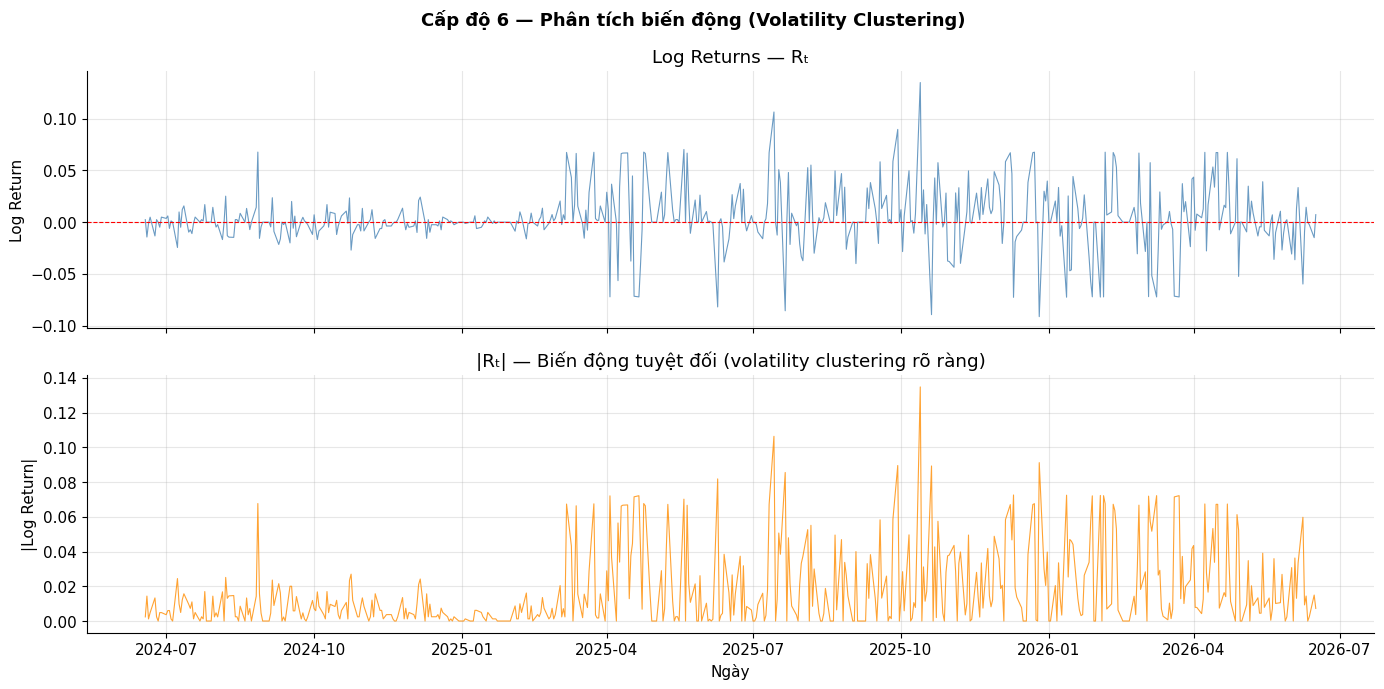

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 VIC.VN   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1180.60
Distribution:                  Normal   AIC:                           2369.20
Method:            Maximum Likelihood   BIC:                           2386.22
                                        No. Observations:                  521
Date:                Wed, Jun 24 2026   Df Residuals:                      520
Time:                        13:04:22   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.0459  9.243e-02      0.497      0.619 [ -0.135,  0.22

In [24]:
from arch import arch_model

# ── 1. Kiểm tra Volatility Clustering ────────────────────────
# Hiện tượng "volatility clustering": biến động lớn theo sau biến động lớn
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle("Cấp độ 6 — Phân tích biến động (Volatility Clustering)", fontsize=13, fontweight="bold")

axes[0].plot(log_returns.index, log_returns.values, lw=0.8, color="steelblue", alpha=0.8)
axes[0].axhline(0, color="red", ls="--", lw=0.8)
axes[0].set_title("Log Returns — Rₜ")
axes[0].set_ylabel("Log Return")

axes[1].plot(log_returns.index, np.abs(log_returns.values), lw=0.8, color="darkorange", alpha=0.8)
axes[1].set_title("|Rₜ| — Biến động tuyệt đối (volatility clustering rõ ràng)")
axes[1].set_ylabel("|Log Return|")
axes[1].set_xlabel("Ngày")

plt.tight_layout()
plt.show()

# ── 2. Fit mô hình GARCH(1,1) ─────────────────────────────────
# GARCH(1,1): σ²_t = ω + α·ε²_{t-1} + β·σ²_{t-1}
lr_pct = log_returns * 100  # Scale thành % để GARCH ổn định hơn

garch_model = arch_model(lr_pct, vol="Garch", p=1, q=1, dist="normal")
garch_fit   = garch_model.fit(disp="off")
print(garch_fit.summary())

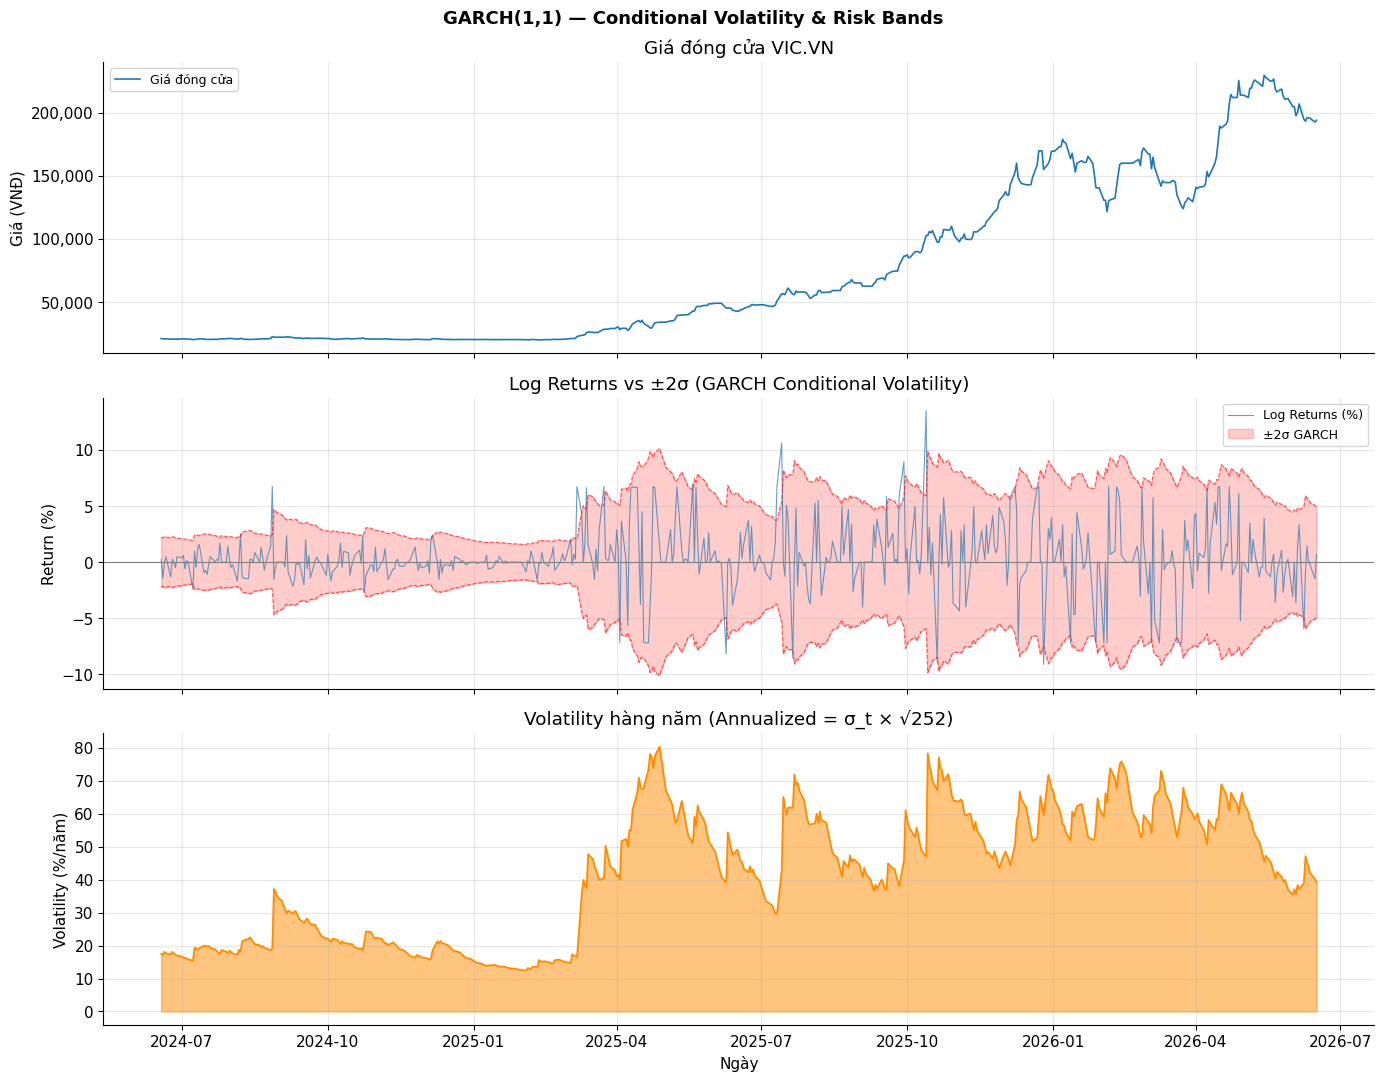


📊 Thống kê Conditional Volatility:
   Volatility TB hàng ngày : 2.6308 (263.08%)
   Volatility TB hàng năm  : 41.76%
   Volatility cao nhất      : 80.38%
   Volatility thấp nhất     : 12.50%


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


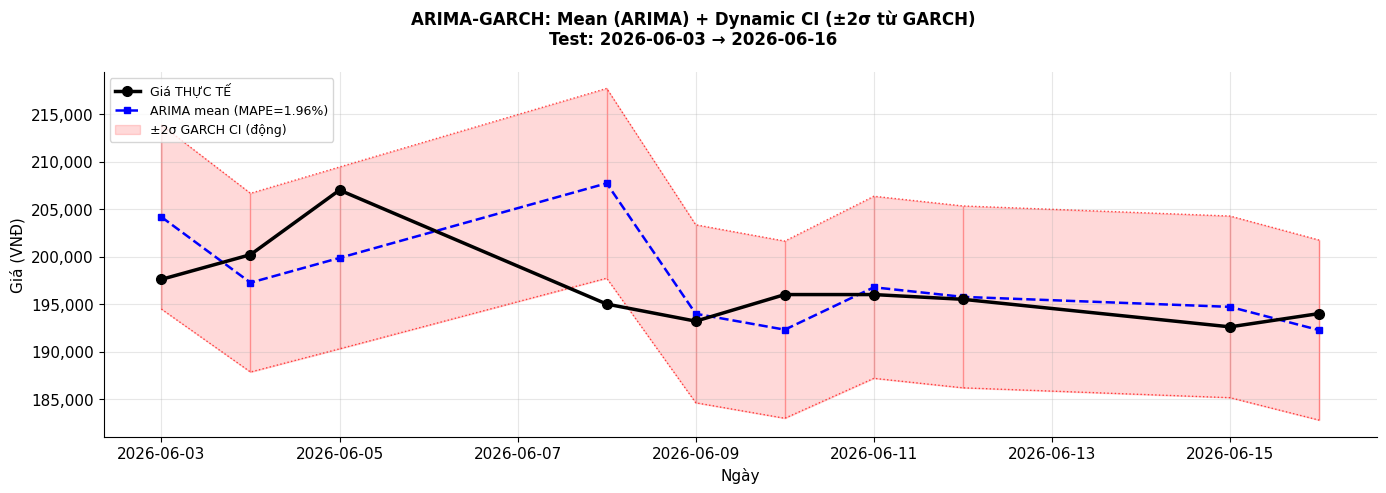


📈 GARCH Volatility Forecast (10 ngày — 03–16/06/2026):
   Ngày + 1: σ = 2.3749%/ngày | 37.70%/năm | CI ≈ ±4.750% quanh mean
   Ngày + 2: σ = 2.3852%/ngày | 37.86%/năm | CI ≈ ±4.770% quanh mean
   Ngày + 3: σ = 2.3954%/ngày | 38.03%/năm | CI ≈ ±4.791% quanh mean
   Ngày + 4: σ = 2.4056%/ngày | 38.19%/năm | CI ≈ ±4.811% quanh mean
   Ngày + 5: σ = 2.4157%/ngày | 38.35%/năm | CI ≈ ±4.831% quanh mean
   Ngày + 6: σ = 2.4258%/ngày | 38.51%/năm | CI ≈ ±4.852% quanh mean
   Ngày + 7: σ = 2.4358%/ngày | 38.67%/năm | CI ≈ ±4.872% quanh mean
   Ngày + 8: σ = 2.4458%/ngày | 38.83%/năm | CI ≈ ±4.892% quanh mean
   Ngày + 9: σ = 2.4558%/ngày | 38.98%/năm | CI ≈ ±4.912% quanh mean
   Ngày +10: σ = 2.4657%/ngày | 39.14%/năm | CI ≈ ±4.931% quanh mean


In [25]:
# =========================================================
# CELL 25: GARCH — CONDITIONAL VOLATILITY & DYNAMIC CI
# =========================================================

# ── Conditional Volatility từ GARCH ───────────────────────────
cond_vol   = garch_fit.conditional_volatility  # σ_t hàng ngày (%)
vol_annual = cond_vol * np.sqrt(252)           # Annualized

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle("GARCH(1,1) — Conditional Volatility & Risk Bands",
             fontsize=13, fontweight="bold")

# Panel 1: Giá đóng cửa
price_aligned = df[log_returns.index]
axes[0].plot(price_aligned.index, price_aligned.values,
             lw=1.2, color="#1f77b4", label="Giá đóng cửa")
axes[0].set_title("Giá đóng cửa VIC.VN")
axes[0].set_ylabel("Giá (VNĐ)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].legend(fontsize=9)

# Panel 2: Log Returns vs ±2σ_t
axes[1].plot(log_returns.index, log_returns.values * 100,
             lw=0.8, color="steelblue", alpha=0.8, label="Log Returns (%)")
axes[1].fill_between(cond_vol.index, -2*cond_vol.values, 2*cond_vol.values,
                     alpha=0.20, color="red", label="±2σ GARCH")
axes[1].plot(cond_vol.index,  2*cond_vol.values, "r--", lw=0.8, alpha=0.6)
axes[1].plot(cond_vol.index, -2*cond_vol.values, "r--", lw=0.8, alpha=0.6)
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].set_title("Log Returns vs ±2σ (GARCH Conditional Volatility)")
axes[1].set_ylabel("Return (%)")
axes[1].legend(fontsize=9)

# Panel 3: Annualized Volatility
axes[2].fill_between(vol_annual.index, 0, vol_annual.values,
                     alpha=0.5, color="darkorange")
axes[2].plot(vol_annual.index, vol_annual.values, lw=1.2, color="darkorange")
axes[2].set_title("Volatility hàng năm (Annualized = σ_t × √252)")
axes[2].set_ylabel("Volatility (%/năm)")
axes[2].set_xlabel("Ngày")

plt.tight_layout()
plt.show()

# ── Thống kê GARCH ────────────────────────────────────────────
print(f"\n📊 Thống kê Conditional Volatility:")
print(f"   Volatility TB hàng ngày : {cond_vol.mean():.4f} ({cond_vol.mean()*100:.2f}%)")
print(f"   Volatility TB hàng năm  : {vol_annual.mean():.2f}%")
print(f"   Volatility cao nhất      : {vol_annual.max():.2f}%")
print(f"   Volatility thấp nhất     : {vol_annual.min():.2f}%")

# ── GARCH Forecast + ARIMA-GARCH Dynamic CI ───────────────────
# Fit ARIMA tốt nhất trên toàn bộ df (không dùng forecasts đã xóa)
final_arima  = ARIMA(df, order=orders[best_model]).fit()
# Forecast TEST_SIZE bước (10 ngày) từ GARCH
garch_fc     = garch_fit.forecast(horizon=TEST_SIZE, reindex=False)
garch_fc_vol = np.sqrt(garch_fc.variance.values[-1])  # σ (%) cho 10 ngày

# ── Vẽ ARIMA mean + GARCH Dynamic CI trên 10 ngày test ────────
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle(f"ARIMA-GARCH: Mean (ARIMA) + Dynamic CI (±2σ từ GARCH)\n"
             f"Test: {test.index[0].date()} → {test.index[-1].date()}",
             fontsize=12, fontweight="bold")

ax.plot(test.index, test.values, "ko-", lw=2.5, ms=7, zorder=5,
        label="Giá THỰC TẾ")
ax.plot(test.index, preds[best_model].values, "b--s", lw=1.8, ms=5,
        label=f"ARIMA mean (MAPE={metrics[best_model]['MAPE']:.2f}%)")

# CI động từ GARCH: chuyển σ (% log return) → VNĐ
for i, (date, price_pred) in enumerate(zip(test.index, preds[best_model].values)):
    sigma_vnd = (garch_fc_vol[i] / 100) * price_pred
    ax.fill_between([date, date],
                    [price_pred - 2 * sigma_vnd],
                    [price_pred + 2 * sigma_vnd],
                    alpha=0.35, color="red")

# Vẽ thêm đường CI nối nhau
ci_upper = preds[best_model].values + (garch_fc_vol / 100) * preds[best_model].values * 2
ci_lower = preds[best_model].values - (garch_fc_vol / 100) * preds[best_model].values * 2
ax.fill_between(test.index, ci_lower, ci_upper,
                alpha=0.15, color="red", label="±2σ GARCH CI (động)")
ax.plot(test.index, ci_upper, "r:", lw=1.0, alpha=0.7)
ax.plot(test.index, ci_lower, "r:", lw=1.0, alpha=0.7)

ax.set_ylabel("Giá (VNĐ)", fontsize=11)
ax.set_xlabel("Ngày", fontsize=11)
ax.legend(loc="upper left", fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

# ── Ghi metrics ARIMA-GARCH ────────────────────────────────────
mae_garch  = metrics[best_model]["MAE"]    # Mean = ARIMA → metrics giống ARIMA
rmse_garch = metrics[best_model]["RMSE"]
mape_garch = metrics[best_model]["MAPE"]
metrics["ARIMA-GARCH"] = {
    "MAE":  mae_garch,
    "RMSE": rmse_garch,
    "MAPE": mape_garch,
    "note": "Mean = ARIMA; CI dynamic từ GARCH"
}

print(f"\n📈 GARCH Volatility Forecast ({TEST_SIZE} ngày — 03–16/06/2026):")
for i, v in enumerate(garch_fc_vol, 1):
    sigma_pct = v       # % hàng ngày
    sigma_ann = v * np.sqrt(252)
    print(f"   Ngày +{i:2d}: σ = {sigma_pct:.4f}%/ngày | {sigma_ann:.2f}%/năm "
          f"| CI ≈ ±{sigma_pct*2:.3f}% quanh mean")


## 14. Cấp độ 7 — ARIMAX: Mô hình tích hợp biến ngoại sinh

⏳ Đang tải dữ liệu biến ngoại sinh...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ^VNINDEX"}}}
$^VNINDEX: possibly delisted; no timezone found

1 Failed download:
['^VNINDEX']: possibly delisted; no timezone found


  ⚠️  VN-Index: Không có dữ liệu
  ✅ USD/VND (USDVND=X): 517 phiên

✅ Exogenous matrix: 522 phiên × 1 biến


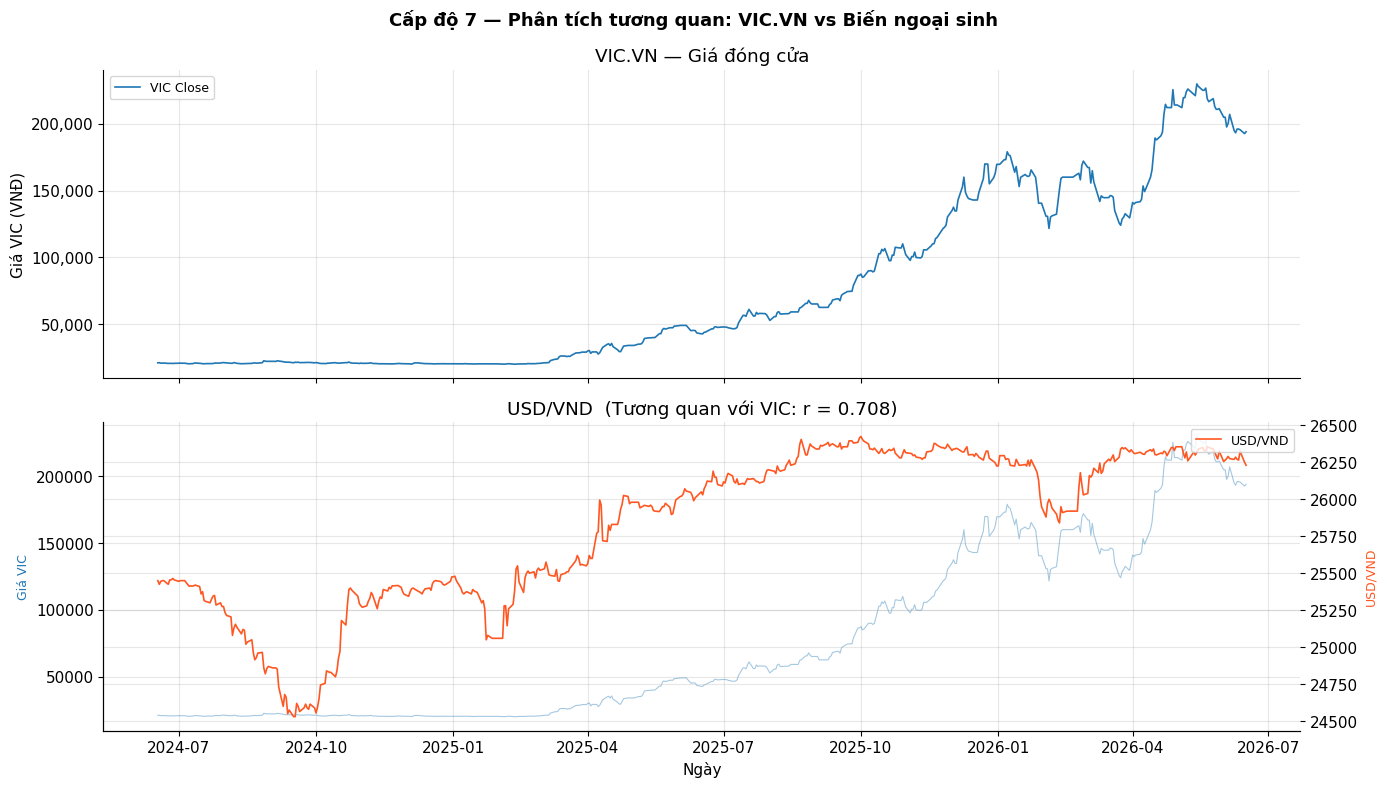

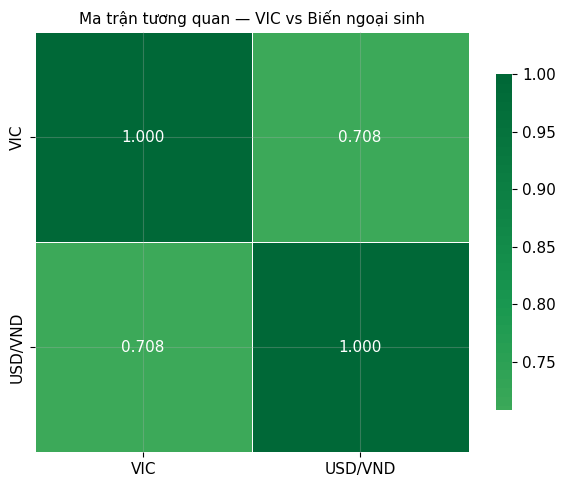

In [27]:
# ── Tải biến ngoại sinh từ Yahoo Finance ─────────────────────
print("⏳ Đang tải dữ liệu biến ngoại sinh...")

exog_raw = {}
tickers_exog = {
    "VN-Index": "^VNINDEX",   # Chỉ số thị trường VN
    "USD/VND":  "USDVND=X",   # Tỷ giá USD/VND
}

for name, ticker in tickers_exog.items():
    try:
        # ✅ Fix: dùng start/end thay vì period=PERIOD (PERIOD đã bị xóa)
        s = yf.download(ticker, start=START_DATE, end=END_DATE,
                        auto_adjust=True, progress=False)["Close"].squeeze()
        s = s.dropna()
        if len(s) > 0:
            exog_raw[name] = s
            print(f"  ✅ {name} ({ticker}): {len(s)} phiên")
        else:
            print(f"  ⚠️  {name}: Không có dữ liệu")
    except Exception as e:
        print(f"  ❌ {name}: {e}")

# Kiểm tra có load được data không
if len(exog_raw) == 0:
    print("⚠️  Không tải được biến ngoại sinh. Kiểm tra kết nối mạng.")
    exog_df = pd.DataFrame(index=df.index)   # DataFrame rỗng để không crash
else:
    # ── Chuẩn hóa và căn chỉnh index ─────────────────────────────
    exog_df = pd.DataFrame(exog_raw)
    exog_df = exog_df.reindex(df.index).ffill().bfill()
    exog_z  = (exog_df - exog_df.mean()) / exog_df.std()
    print(f"\n✅ Exogenous matrix: {exog_z.shape[0]} phiên × {exog_z.shape[1]} biến")

    # ── Biểu đồ tương quan VIC vs các biến ngoại sinh ────────────
    n_panels = len(exog_df.columns) + 1
    fig, axes = plt.subplots(n_panels, 1,
                             figsize=(14, 4 * n_panels),
                             sharex=True)
    # ✅ Fix: đảm bảo axes luôn là array kể cả khi chỉ có 1 panel
    import numpy as np
    axes = np.atleast_1d(axes)

    fig.suptitle("Cấp độ 7 — Phân tích tương quan: VIC.VN vs Biến ngoại sinh",
                 fontsize=13, fontweight="bold")

    # Panel 0: VIC price
    axes[0].plot(df.index, df.values, lw=1.2, color="#1f77b4", label="VIC Close")
    axes[0].set_ylabel("Giá VIC (VNĐ)")
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    axes[0].legend(fontsize=9)
    axes[0].set_title("VIC.VN — Giá đóng cửa")

    # Panel 1+: Từng biến ngoại sinh
    colors_exog = ["#FF5722", "#9C27B0", "#009688"]
    for ax, (col, color) in zip(axes[1:], zip(exog_df.columns, colors_exog)):
        ax2  = ax.twinx()
        ax.plot(df.index, df.values, lw=0.8, color="#1f77b4", alpha=0.4)
        ax2.plot(exog_df.index, exog_df[col].values, lw=1.2, color=color, label=col)
        corr = df.corr(exog_df[col])
        ax.set_ylabel("Giá VIC", color="#1f77b4", fontsize=9)
        ax2.set_ylabel(col, color=color, fontsize=9)
        ax.set_title(f"{col}  (Tương quan với VIC: r = {corr:.3f})")
        ax2.legend(fontsize=9, loc="upper right")

    axes[-1].set_xlabel("Ngày")
    plt.tight_layout()
    plt.show()

    # ── Ma trận tương quan ────────────────────────────────────────
    corr_data = pd.concat([df.rename("VIC"), exog_df], axis=1)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(corr_data.corr(), annot=True, fmt=".3f", cmap="RdYlGn",
                center=0, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title("Ma trận tương quan — VIC vs Biến ngoại sinh", fontsize=11)
    plt.tight_layout()
    plt.show()


⏳ ARIMAX Rolling Forecast...


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

✅ ARIMAX hoàn thành
   MAE  = 3,873.0 VNĐ
   RMSE = 5,357.4 VNĐ
   MAPE = 1.96%


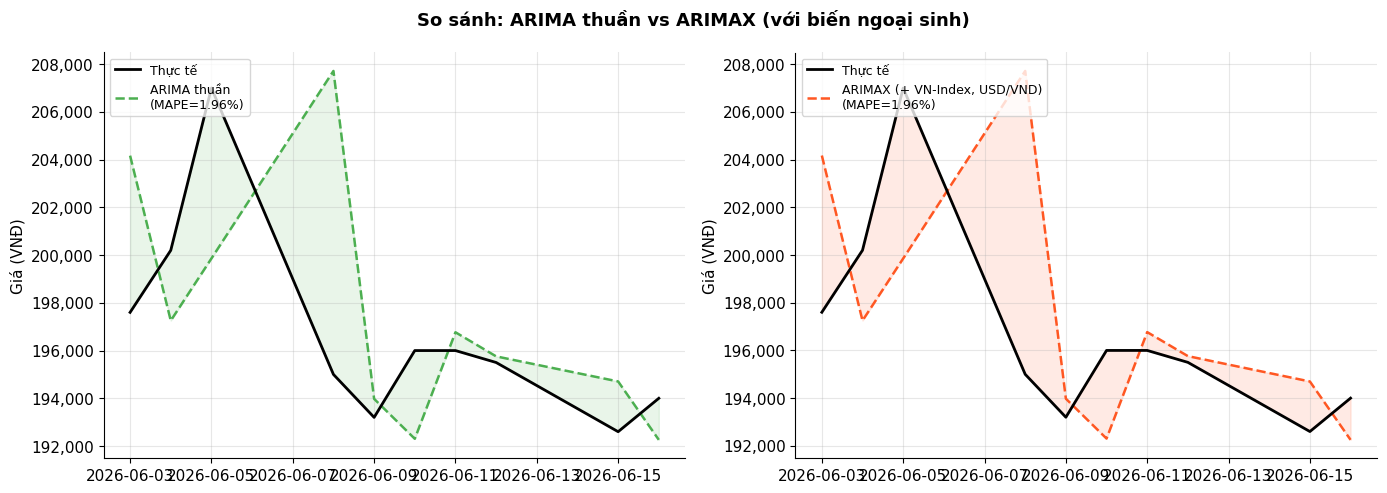

In [28]:
# ── Chuẩn bị dữ liệu ARIMAX ───────────────────────────────────
exog_train = exog_z.iloc[:-TEST_SIZE].values
exog_test  = exog_z.iloc[-TEST_SIZE:].values

# ── Rolling Forecast ARIMAX ───────────────────────────────────
print("⏳ ARIMAX Rolling Forecast...")
fc_arimax = []
for i in range(TEST_SIZE):
    wd       = df.iloc[:-(TEST_SIZE - i)]
    wd_exog  = exog_z.iloc[:-(TEST_SIZE - i)].values
    fc_exog  = exog_z.iloc[-(TEST_SIZE - i)].values.reshape(1, -1)
    try:
        m = ARIMA(wd, order=(p_opt, d_opt, q_opt), exog=wd_exog).fit()
        fc_arimax.append(m.forecast(steps=1, exog=fc_exog).iloc[0])
    except:
        # Fallback: dùng ARIMA thuần nếu ARIMAX không hội tụ
        m = ARIMA(wd, order=(p_opt, d_opt, q_opt)).fit()
        fc_arimax.append(m.forecast(1).iloc[0])

pred_arimax = pd.Series(fc_arimax, index=test.index)

mae_ax  = mean_absolute_error(test, pred_arimax)
rmse_ax = np.sqrt(mean_squared_error(test, pred_arimax))
mape_ax = np.mean(np.abs((test.values - pred_arimax.values) / test.values)) * 100
metrics["ARIMAX"] = {"MAE": mae_ax, "RMSE": rmse_ax, "MAPE": mape_ax}

print(f"✅ ARIMAX hoàn thành")
print(f"   MAE  = {mae_ax:,.1f} VNĐ")
print(f"   RMSE = {rmse_ax:,.1f} VNĐ")
print(f"   MAPE = {mape_ax:.2f}%")

# ── Biểu đồ so sánh ARIMA vs ARIMAX ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("So sánh: ARIMA thuần vs ARIMAX (với biến ngoại sinh)",
             fontsize=13, fontweight="bold")

for ax, (name, pred, color) in zip(axes, [
    ("ARIMA thuần", preds[best_model], "#4CAF50"),
    ("ARIMAX (+ VN-Index, USD/VND)", pred_arimax, "#FF5722"),
]):
    mape_v = np.mean(np.abs((test.values - pred.values) / test.values)) * 100
    ax.plot(test.index, test.values, "k-", lw=2.0, label="Thực tế", zorder=3)
    ax.plot(pred.index, pred.values, "--", lw=1.8, color=color,
            label=f"{name}\n(MAPE={mape_v:.2f}%)")
    ax.fill_between(test.index, test.values, pred.values, alpha=0.12, color=color)
    ax.set_ylabel("Giá (VNĐ)")
    ax.legend(fontsize=9, loc="upper left")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

## 15. So sánh toàn diện — Truyền thống (AR/MA/ARIMA) vs 7 Cấp độ

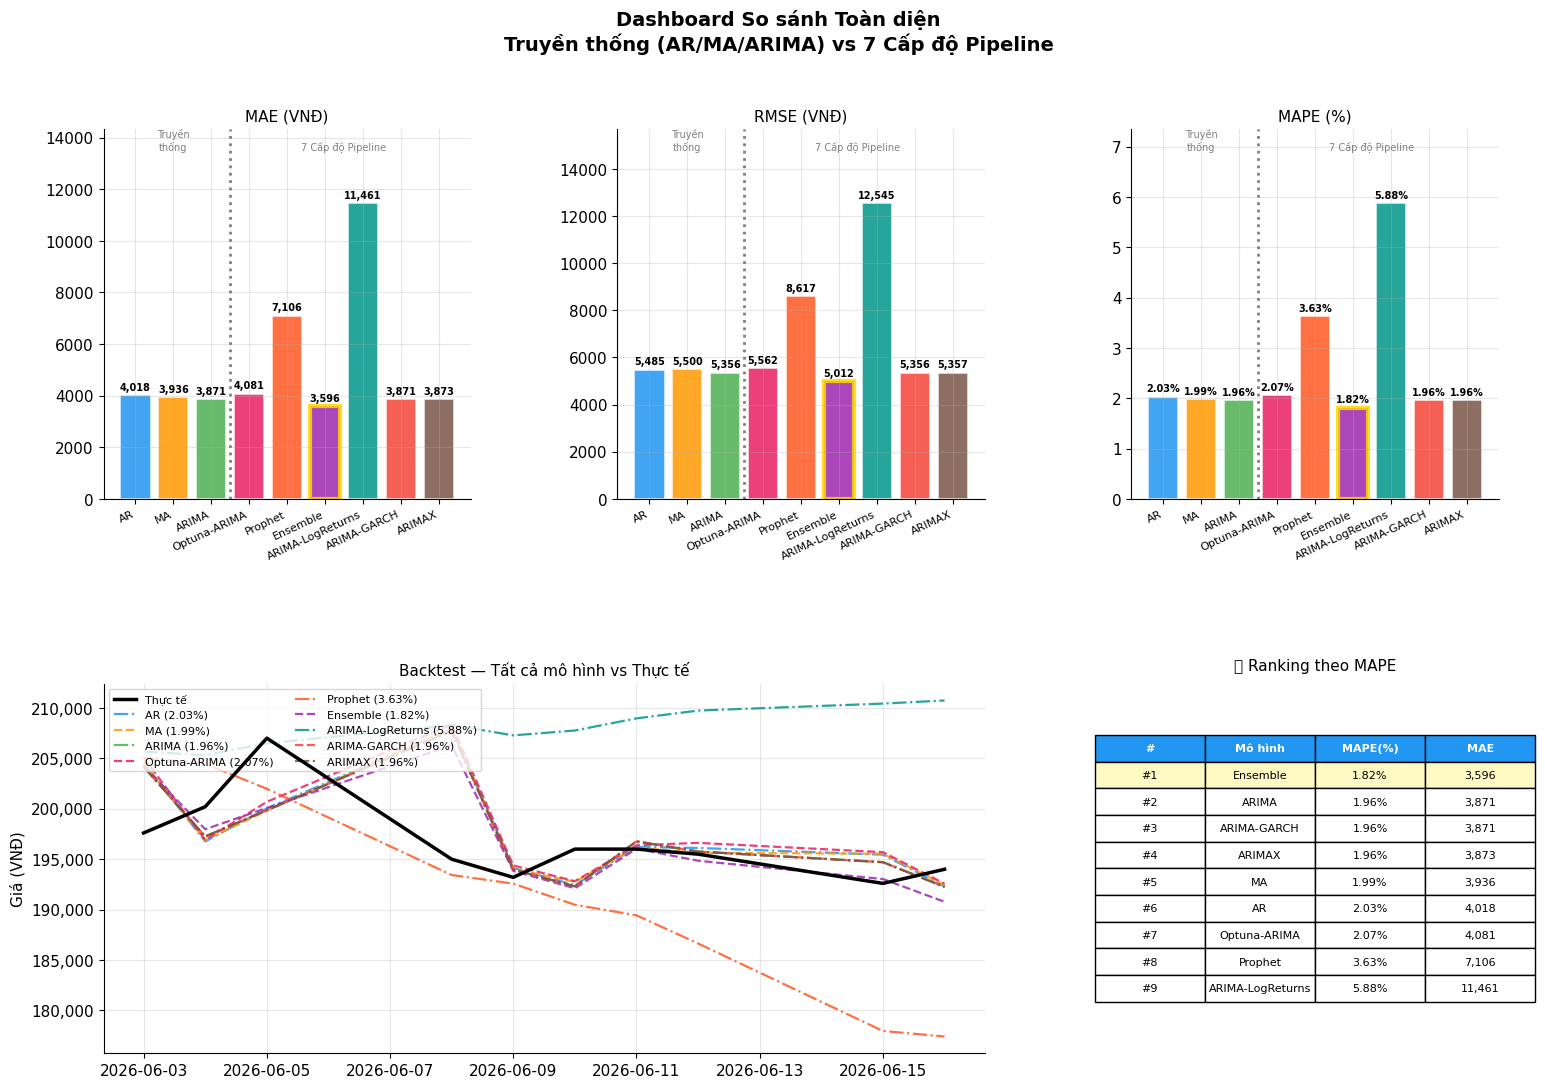

In [29]:
# ── Tổng hợp tất cả metrics ───────────────────────────────────
# AR/MA/ARIMA: đúng như VIC_ARIMA_analysis.md (baseline bài tập)
# Các mô hình nâng cao: bổ sung thêm để so sánh và đánh giá
traditional_models = ["AR", "MA", "ARIMA"]   # Baseline theo yêu cầu bài tập
advanced_models    = [                        # 6 cải tiến pipeline
    "Optuna-ARIMA",      # Tối ưu out-of-sample (Bayesian)
    "Prophet",           # Decomposable Time Series (Meta)
    "Ensemble",          # Kết hợp ARIMA + Prophet
    "ARIMA-LogReturns",  # Mô hình hóa trên lợi suất logarit
    "ARIMA-GARCH",       # Volatility modeling
    "ARIMAX",            # Tích hợp biến ngoại sinh
]

all_model_names = traditional_models + advanced_models
all_maes   = [metrics[m]["MAE"]  for m in all_model_names]
all_rmses  = [metrics[m]["RMSE"] for m in all_model_names]
all_mapes  = [metrics[m]["MAPE"] for m in all_model_names]

# Map tên → Series dự báo (để vẽ overlay)
model_preds_map = {
    "AR":               preds["AR"],
    "MA":               preds["MA"],
    "ARIMA":            preds["ARIMA"],        # Grid Search AIC result
    "Optuna-ARIMA":     pred_optuna,
    "Prophet":          pred_prophet,
    "Ensemble":         pred_ensemble,
    "ARIMA-LogReturns": pred_prices_lr,
    "ARIMAX":           pred_arimax,
    "ARIMA-GARCH":      preds["ARIMA"],        # Mean = ARIMA; GARCH cung cấp CI
}

bar_colors_all = [
    "#2196F3", "#FF9800", "#4CAF50",           # Truyền thống: AR, MA, ARIMA
    "#E91E63", "#FF5722", "#9C27B0",           # Nâng cao: Optuna, Prophet, Ensemble
    "#009688", "#F44336", "#795548",           # Nâng cao: LogReturns, GARCH, ARIMAX
]


# ── Dashboard 2×3 ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Dashboard So sánh Toàn diện\n"
             "Truyền thống (AR/MA/ARIMA) vs 7 Cấp độ Pipeline",
             fontsize=14, fontweight="bold")

gs = fig.add_gridspec(2, 3, hspace=0.50, wspace=0.40)

# ── Row 1: Bar charts MAE / RMSE / MAPE ──────────────────────
ax_mae  = fig.add_subplot(gs[0, 0])
ax_rmse = fig.add_subplot(gs[0, 1])
ax_mape = fig.add_subplot(gs[0, 2])

for ax, vals, metric, unit in zip(
    [ax_mae, ax_rmse, ax_mape],
    [all_maes, all_rmses, all_mapes],
    ["MAE", "RMSE", "MAPE"],
    ["VNĐ", "VNĐ", "%"]
):
    bars = ax.bar(range(len(all_model_names)), vals, color=bar_colors_all,
                  alpha=0.85, edgecolor="white", linewidth=1.2)
    # Annotate
    for bar, val in zip(bars, vals):
        label = f"{val:.2f}%" if metric == "MAPE" else f"{val:,.0f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                label, ha="center", va="bottom", fontsize=7, fontweight="bold")
    # Highlight best
    best_idx = int(np.argmin(vals))
    bars[best_idx].set_edgecolor("gold")
    bars[best_idx].set_linewidth(3)
    # Đường phân cách: Truyền thống (3 model) | 7 Cấp độ (6 model)
    ax.axvline(2.5, color="gray", ls=":", lw=2.0)
    ax.text(1.0,   max(vals)*1.18, "Truyền\nthống", ha="center", fontsize=7, color="gray")
    ax.text(5.5,   max(vals)*1.18, "7 Cấp độ Pipeline",   ha="center", fontsize=7, color="gray")
    ax.set_title(f"{metric} ({unit})", fontsize=11)
    ax.set_xticks(range(len(all_model_names)))
    ax.set_xticklabels(all_model_names, rotation=25, ha="right", fontsize=8)
    ax.set_ylim(0, max(vals) * 1.25)

# ── Row 2, Col 0-1: Biểu đồ dự báo overlay tất cả mô hình ────
ax_fc = fig.add_subplot(gs[1, :2])
ax_fc.plot(test.index, test.values, "k-", lw=2.5, label="Thực tế", zorder=10)
line_styles = ["-.", "--", "-.", "--", "-.", "--", "-.", "--", "-."]
for name, color, ls in zip(all_model_names, bar_colors_all, line_styles):
    pred = model_preds_map.get(name)
    if pred is None:
        continue
    mape_v = metrics[name]["MAPE"]
    ax_fc.plot(pred.index, pred.values, ls, lw=1.6, color=color,
               label=f"{name} ({mape_v:.2f}%)", alpha=0.85)

ax_fc.set_title("Backtest — Tất cả mô hình vs Thực tế", fontsize=11)
ax_fc.set_ylabel("Giá (VNĐ)")
ax_fc.legend(fontsize=8, ncol=2, loc="upper left")
ax_fc.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# ── Row 2, Col 2: Bảng ranking ────────────────────────────────
ax_tbl = fig.add_subplot(gs[1, 2])
ax_tbl.axis("off")

rank_data = sorted(
    [(n, metrics[n]["MAPE"], metrics[n]["MAE"], metrics[n]["RMSE"])
     for n in all_model_names],
    key=lambda x: x[1]
)
tbl_vals   = [["#", "Mô hình", "MAPE(%)", "MAE"]] + \
             [[f"#{i+1}", r[0], f"{r[1]:.2f}%", f"{r[2]:,.0f}"]
              for i, r in enumerate(rank_data)]
tbl        = ax_tbl.table(cellText=tbl_vals[1:], colLabels=tbl_vals[0],
                           loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.2, 1.6)
# Tô màu header
for j in range(4):
    tbl[0, j].set_facecolor("#2196F3")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
# Tô màu #1 (vàng)
for j in range(4):
    tbl[1, j].set_facecolor("#FFF9C4")
ax_tbl.set_title("🏆 Ranking theo MAPE", fontsize=11, pad=10)

plt.savefig("model_comparison_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

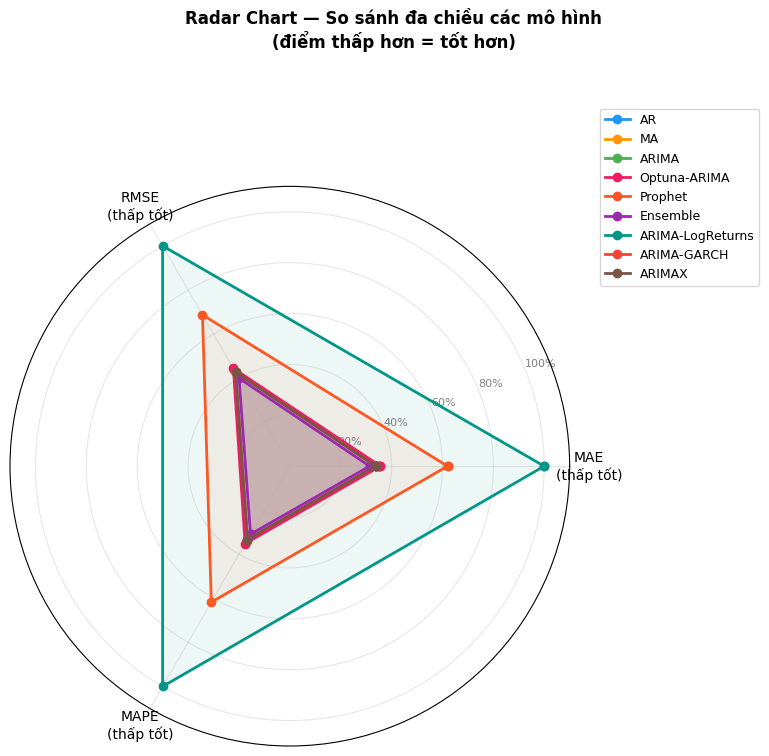

  KẾT LUẬN TOÀN DIỆN — So sánh Truyền thống vs 7 Cấp độ Nâng cao

  Nhóm            Mô hình                     MAE       RMSE      MAPE  Rank
  ────────────────────────────────────────────────────────────────────────
  Nâng cao        Ensemble                  3,596      5,012     1.82%   🏆
  Truyền thống    ARIMA                     3,871      5,356     1.96%    #2
  Nâng cao        ARIMA-GARCH               3,871      5,356     1.96%    #3
  Nâng cao        ARIMAX                    3,873      5,357     1.96%  
  Truyền thống    MA                        3,936      5,500     1.99%  
  Truyền thống    AR                        4,018      5,485     2.03%  
  Nâng cao        Optuna-ARIMA              4,081      5,562     2.07%  
  Nâng cao        Prophet                   7,106      8,617     3.63%  
  Nâng cao        ARIMA-LogReturns         11,461     12,545     5.88%  

  ────────────────────────────────────────────────────────────────────────
  🏆 Tốt nhất tổng thể    : Ensemble (MA

In [30]:
# ── Radar Chart: so sánh đa chiều ─────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = ["MAE\n(thấp tốt)", "RMSE\n(thấp tốt)", "MAPE\n(thấp tốt)"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle("Radar Chart — So sánh đa chiều các mô hình\n(điểm thấp hơn = tốt hơn)",
             fontsize=12, fontweight="bold")

# Chuẩn hóa: giá trị 0-1 (thấp = tốt)
max_mae, max_rmse, max_mape = (max(all_maes), max(all_rmses), max(all_mapes))
for name, color in zip(all_model_names, bar_colors_all):
    m = metrics[name]
    values = [
        m["MAE"]  / max_mae,
        m["RMSE"] / max_rmse,
        m["MAPE"] / max_mape,
    ] + [m["MAE"] / max_mae]
    ax.plot(angles, values, "o-", lw=2, color=color, label=name)
    ax.fill(angles, values, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["20%", "40%", "60%", "80%", "100%"], fontsize=8, color="gray")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

# ── Bảng tổng kết cuối cùng ───────────────────────────────────
print("=" * 75)
print(f"  KẾT LUẬN TOÀN DIỆN — So sánh Truyền thống vs 7 Cấp độ Nâng cao")
print("=" * 75)
print(f"\n  {'Nhóm':<15} {'Mô hình':<20} {'MAE':>10} {'RMSE':>10} {'MAPE':>9}  Rank")
print(f"  {'─'*72}")

ranked = sorted(all_model_names, key=lambda n: metrics[n]["MAPE"])
for rank, name in enumerate(ranked, 1):
    m    = metrics[name]
    grp  = "Truyền thống" if name in traditional_models else "Nâng cao    "
    tag  = " 🏆" if rank == 1 else ("" if rank > 3 else f"  #{rank}")
    print(f"  {grp:<15} {name:<20} {m['MAE']:>10,.0f} {m['RMSE']:>10,.0f} {m['MAPE']:>8.2f}%  {tag}")

print(f"\n  {'─'*72}")
best_all  = ranked[0]
best_trad = min(traditional_models, key=lambda n: metrics[n]["MAPE"])
print(f"  🏆 Tốt nhất tổng thể    : {best_all} (MAPE={metrics[best_all]['MAPE']:.2f}%)")
print(f"  🥇 Tốt nhất truyền thống : {best_trad} (MAPE={metrics[best_trad]['MAPE']:.2f}%)")
improvement = (metrics[best_trad]["MAPE"] - metrics[best_all]["MAPE"]) / metrics[best_trad]["MAPE"] * 100
if improvement > 0:
    print(f"  📈 Cải thiện MAPE        : {improvement:.1f}% (so với mô hình truyền thống tốt nhất)")
print("=" * 75)